# Regional Importance Scoring — Spatial Visualization

This notebook loads Gemma 3 1B, divides every weight matrix into tiles, scores each tile's importance, and produces **spatial heatmaps** showing which rectangular regions of each layer are critical vs. expendable.

The heatmaps let you literally *see* the model's internal structure — where the "reasoning circuits" live and where the dead weight is.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from collections import defaultdict

import config

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

## 1. Load model

In [2]:
print(f"Loading {config.MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    config.MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params / 1e9:.2f}B")
print(f"GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Loading google/gemma-3-1b-it...
Parameters: 1.00B
GPU memory: 2.60 GB


## 2. Inspect model architecture

Let's see what layers and weight matrices we're working with.

In [3]:
# Collect all 2D weight matrices (the ones we can tile-prune)
weight_info = []
for name, param in model.named_parameters():
    if param.ndim == 2:
        weight_info.append((name, param.shape, param.numel()))
        
print(f"Found {len(weight_info)} weight matrices:\n")
for name, shape, numel in weight_info:
    print(f"  {name:<60s} {str(list(shape)):>20s}  ({numel/1e6:.1f}M)")

Found 183 weight matrices:

  model.embed_tokens.weight                                          [262144, 1152]  (302.0M)
  model.layers.0.self_attn.q_proj.weight                               [1024, 1152]  (1.2M)
  model.layers.0.self_attn.k_proj.weight                                [256, 1152]  (0.3M)
  model.layers.0.self_attn.v_proj.weight                                [256, 1152]  (0.3M)
  model.layers.0.self_attn.o_proj.weight                               [1152, 1024]  (1.2M)
  model.layers.0.mlp.gate_proj.weight                                  [6912, 1152]  (8.0M)
  model.layers.0.mlp.up_proj.weight                                    [6912, 1152]  (8.0M)
  model.layers.0.mlp.down_proj.weight                                  [1152, 6912]  (8.0M)
  model.layers.1.self_attn.q_proj.weight                               [1024, 1152]  (1.2M)
  model.layers.1.self_attn.k_proj.weight                                [256, 1152]  (0.3M)
  model.layers.1.self_attn.v_proj.weight          

## 3. Tile importance scoring

Two methods:
1. **Frobenius norm** — `||W_tile||_F` (weight magnitude only, cheap baseline)
2. **Activation-weighted** — `||W_tile||_F * mean(||x_inputs||)` (accounts for how much each tile is actually used during inference)

The activation-weighted method requires a calibration pass over real data.

In [4]:
TILE_R, TILE_C = config.TILE_SIZES[0]

def compute_tile_importance(weight: torch.Tensor, tile_r: int = TILE_R, tile_c: int = TILE_C) -> np.ndarray:
    """
    Compute Frobenius norm of each (tile_r, tile_c) tile in a 2D weight matrix.
    Returns a 2D numpy array of shape (n_row_tiles, n_col_tiles).
    """
    W = weight.detach().float().cpu()
    out_dim, in_dim = W.shape
    
    n_rows = out_dim // tile_r
    n_cols = in_dim // tile_c
    
    # Trim to tile-aligned dimensions
    W_trimmed = W[:n_rows * tile_r, :n_cols * tile_c]
    
    # Reshape into tiles: (n_rows, tile_r, n_cols, tile_c)
    tiles = W_trimmed.reshape(n_rows, tile_r, n_cols, tile_c)
    tiles = tiles.permute(0, 2, 1, 3)  # (n_rows, n_cols, tile_r, tile_c)
    
    # Frobenius norm per tile
    norms = tiles.reshape(n_rows, n_cols, -1).norm(dim=-1)  # (n_rows, n_cols)
    
    return norms.numpy()

def get_component_type(name: str) -> str:
    """Extract component type (e.g. 'gate_proj') from a full parameter name."""
    for pattern in config.PRUNE_TARGETS_PATTERNS:
        if pattern in name:
            return pattern
    return "unknown"

print(f"Tile size: ({TILE_R}, {TILE_C})")

Tile size: (128, 128)


In [5]:
# Score all weight matrices and organize by layer + component type
# Raw maps are used for visualization (show actual magnitude).
# Normalized maps (per component type) are used for pruning decisions.
# Per-component-type normalization fixes the scale gap between e.g. down_proj
# and gate_proj, while preserving cross-layer variation within each type
# (so some layers can still be pruned more aggressively than others).

importance_maps_all = {}       # ALL raw maps (for visualization)
importance_maps_mlp = {}       # MLP raw maps (for visualization)
layer_components = defaultdict(dict)       # raw, for heatmaps

SKIP_PATTERNS = ["embed_tokens", "lm_head"]

def is_mlp(name: str) -> bool:
    return any(k in name for k in config.PRUNE_TARGETS_PATTERNS)

# --- Pass 1: compute raw importance for all matrices ---
for name, param in model.named_parameters():
    if param.ndim != 2:
        continue
    if any(skip in name for skip in SKIP_PATTERNS):
        continue
    
    out_dim, in_dim = param.shape
    if out_dim < TILE_R or in_dim < TILE_C:
        continue
    
    imp_raw = compute_tile_importance(param)
    importance_maps_all[name] = imp_raw
    if is_mlp(name):
        importance_maps_mlp[name] = imp_raw
    
    parts = name.split(".")
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            layer_idx = int(parts[i + 1])
            comp_name = ".".join(parts[i + 2:]).replace(".weight", "")
            layer_components[layer_idx][comp_name] = imp_raw
            break

# --- Pass 2: compute per-component-type statistics, then normalize ---
comp_type_stats = {}  # comp_type -> (mean, std)
for comp_type in config.PRUNE_TARGETS_PATTERNS:
    all_vals = np.concatenate([
        m.ravel() for name, m in importance_maps_mlp.items()
        if comp_type in name
    ])
    comp_type_stats[comp_type] = (all_vals.mean(), all_vals.std())
    print(f"  {comp_type}: mean={all_vals.mean():.3f}, std={all_vals.std():.3f} ({len(all_vals)} tiles)")

importance_maps_mlp_norm = {}
layer_components_norm = defaultdict(dict)

for name, raw_map in importance_maps_mlp.items():
    comp_type = get_component_type(name)
    mean, std = comp_type_stats[comp_type]
    norm_map = (raw_map - mean) / std if std > 1e-8 else np.zeros_like(raw_map)
    importance_maps_mlp_norm[name] = norm_map
    
    parts = name.split(".")
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            layer_idx = int(parts[i + 1])
            comp_name = ".".join(parts[i + 2:]).replace(".weight", "")
            layer_components_norm[layer_idx][comp_name] = norm_map
            break

n_layers = len(layer_components)
print(f"\nScored {len(importance_maps_all)} weight matrices across {n_layers} layers")
print(f"  MLP (pruning targets):  {len(importance_maps_mlp)} matrices")
print(f"  Attention (view only):  {len(importance_maps_all) - len(importance_maps_mlp)} matrices")
print(f"  Normalization: per component type (preserves cross-layer variation)")

  gate_proj: mean=3.815, std=0.141 (12636 tiles)
  up_proj: mean=3.818, std=0.128 (12636 tiles)
  down_proj: mean=1.264, std=0.276 (12636 tiles)

Scored 182 weight matrices across 26 layers
  MLP (pruning targets):  78 matrices
  Attention (view only):  104 matrices
  Normalization: per component type (preserves cross-layer variation)


## 3b. Activation-weighted importance scoring

Run a calibration set through the model, hook into each MLP linear layer, and capture input activation statistics. Then score each tile as:

`score(tile_r, tile_c) = ||W[r, c]||_F * mean(||x[:, c_start:c_end]||)`

This captures whether a tile's input features are actually "live" during inference.

In [6]:
from datasets import load_dataset

# --- Load calibration data ---
print("Loading calibration data...")
cal_ds = load_dataset(
    config.CALIBRATION_DATASET,
    config.CALIBRATION_SUBSET,
    split="train",
    streaming=True,
    trust_remote_code=True,
)

cal_texts = []
for i, example in enumerate(cal_ds):
    if i >= config.CALIBRATION_SAMPLES:
        break
    text = example.get("text", "")
    if len(text) > 50:
        cal_texts.append(text)

print(f"Loaded {len(cal_texts)} calibration samples")

# Tokenize
cal_encodings = []
for text in cal_texts:
    enc = tokenizer(
        text,
        return_tensors="pt",
        max_length=config.CALIBRATION_SEQ_LEN,
        truncation=True,
    )
    cal_encodings.append(enc)

print(f"Tokenized {len(cal_encodings)} samples (max {config.CALIBRATION_SEQ_LEN} tokens each)")

Loading calibration data...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Loaded 1022 calibration samples
Tokenized 1022 samples (max 512 tokens each)


In [7]:
from tqdm import tqdm

# --- Hook into MLP layers and collect input activation norms ---
# For each MLP linear (gate_proj, up_proj, down_proj), we accumulate
# the squared L2 norm of each input feature slice (per tile column).

activation_stats = {}  # param_name -> (sum_of_squared_norms, count)
hooks = []

def make_hook(param_name, in_dim):
    """Create a forward hook that accumulates input activation norms per tile column."""
    n_cols = in_dim // TILE_C
    
    def hook_fn(module, input, output):
        x = input[0].detach().float()  # (batch, seq_len, in_dim)
        x = x.reshape(-1, x.shape[-1])  # (tokens, in_dim)
        x_trimmed = x[:, :n_cols * TILE_C]  # trim to tile-aligned
        
        # Reshape to (tokens, n_cols, TILE_C) and compute norm per column tile
        x_tiles = x_trimmed.reshape(x_trimmed.shape[0], n_cols, TILE_C)
        col_norms = x_tiles.norm(dim=-1).mean(dim=0)  # (n_cols,) mean over tokens
        
        if param_name not in activation_stats:
            activation_stats[param_name] = (col_norms.cpu(), 1)
        else:
            prev_sum, prev_count = activation_stats[param_name]
            activation_stats[param_name] = (prev_sum + col_norms.cpu(), prev_count + 1)
    
    return hook_fn

# Register hooks on all MLP linear layers
for name, module in model.named_modules():
    if not isinstance(module, torch.nn.Linear):
        continue
    param_name = name + ".weight"
    if not is_mlp(param_name):
        continue
    
    in_dim = module.in_features
    if in_dim < TILE_C:
        continue
    
    h = module.register_forward_hook(make_hook(param_name, in_dim))
    hooks.append(h)

print(f"Registered {len(hooks)} hooks on MLP layers")

# --- Run calibration pass ---
print(f"Running calibration pass ({len(cal_encodings)} samples)...")
with torch.no_grad():
    for enc in tqdm(cal_encodings, desc="Calibration"):
        inputs = {k: v.to(config.DEVICE) for k, v in enc.items()}
        model(**inputs)

# Remove hooks
for h in hooks:
    h.remove()

print(f"Calibration complete. Collected stats for {len(activation_stats)} matrices.")

Registered 78 hooks on MLP layers
Running calibration pass (1022 samples)...


Calibration: 100%|███████████████████████████████████████████████| 1022/1022 [00:52<00:00, 19.46it/s]

Calibration complete. Collected stats for 78 matrices.


In [8]:
# --- Compute activation-weighted importance maps ---
# score(tile_r, tile_c) = ||W_tile||_F * mean(||x_col_tile||)
# The Frobenius norm tells us "how big is this tile", the activation norm
# tells us "how active are the inputs feeding this tile". The product captures
# the tile's actual contribution to the layer output.

importance_maps_actw = {}  # name -> 2D numpy array (raw activation-weighted)

for name, frob_map in importance_maps_mlp.items():
    if name not in activation_stats:
        continue
    
    col_norm_sum, count = activation_stats[name]
    mean_col_norms = (col_norm_sum / count).numpy()  # (n_cols,)
    
    # frob_map is (n_row_tiles, n_col_tiles), mean_col_norms is (n_col_tiles,)
    # Broadcast: each column's activation norm multiplies all row tiles in that column
    actw_map = frob_map * mean_col_norms[np.newaxis, :]
    importance_maps_actw[name] = actw_map

print(f"Activation-weighted maps computed for {len(importance_maps_actw)} matrices")

# --- Normalize per component type (same strategy as Frobenius) ---
importance_maps_actw_norm = {}
layer_components_actw = defaultdict(dict)
layer_components_actw_norm = defaultdict(dict)

comp_type_stats_actw = {}
for comp_type in config.PRUNE_TARGETS_PATTERNS:
    all_vals = np.concatenate([
        m.ravel() for name, m in importance_maps_actw.items()
        if comp_type in name
    ])
    comp_type_stats_actw[comp_type] = (all_vals.mean(), all_vals.std())
    print(f"  {comp_type}: mean={all_vals.mean():.3f}, std={all_vals.std():.3f}")

for name, actw_map in importance_maps_actw.items():
    comp_type = get_component_type(name)
    mean, std = comp_type_stats_actw[comp_type]
    norm_map = (actw_map - mean) / std if std > 1e-8 else np.zeros_like(actw_map)
    importance_maps_actw_norm[name] = norm_map
    
    parts = name.split(".")
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            layer_idx = int(parts[i + 1])
            comp_name = ".".join(parts[i + 2:]).replace(".weight", "")
            layer_components_actw[layer_idx][comp_name] = actw_map
            layer_components_actw_norm[layer_idx][comp_name] = norm_map
            break

print(f"\nActivation-weighted scoring ready. Comparing with Frobenius...")

Activation-weighted maps computed for 78 matrices
  gate_proj: mean=23.263, std=12.796
  up_proj: mean=23.253, std=12.665
  down_proj: mean=1.814, std=1.700

Activation-weighted scoring ready. Comparing with Frobenius...


## 3c. Gradient-based importance scoring (Taylor approximation)

Score each tile by `Σ|w * ∂L/∂w|` — the first-order Taylor approximation of the change in loss from zeroing that tile. This captures weight magnitude, input activations, AND downstream loss sensitivity in a single metric.

Requires forward + backward pass over calibration data.

In [9]:
# --- Gradient-based calibration pass ---
# For each calibration sample, run forward + backward and accumulate
# |w * ∂L/∂w| per tile (Taylor importance).

gradient_importance_accum = {}  # param_name -> accumulated tile importance (numpy)
n_grad_samples = 0

print(f"Running gradient calibration pass ({len(cal_encodings)} samples, forward+backward)...")

for enc in tqdm(cal_encodings, desc="Gradient calibration"):
    model.zero_grad()
    inputs = {k: v.to(config.DEVICE) for k, v in enc.items()}
    
    # Forward pass with labels = input_ids (language modeling loss)
    outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss
    
    # Backward pass
    loss.backward()
    
    # Accumulate Taylor importance per MLP weight tile
    for name, param in model.named_parameters():
        if not is_mlp(name):
            continue
        if param.grad is None:
            continue
        if param.ndim != 2:
            continue
        
        out_dim, in_dim = param.shape
        n_rows = out_dim // TILE_R
        n_cols = in_dim // TILE_C
        if n_rows == 0 or n_cols == 0:
            continue
        
        # Taylor importance: |w * grad|
        taylor = (param.data * param.grad).abs().float().cpu()
        taylor_trimmed = taylor[:n_rows * TILE_R, :n_cols * TILE_C]
        
        # Sum within each tile
        tiles = taylor_trimmed.reshape(n_rows, TILE_R, n_cols, TILE_C)
        tiles = tiles.permute(0, 2, 1, 3)
        tile_scores = tiles.reshape(n_rows, n_cols, -1).sum(dim=-1).numpy()
        
        if name not in gradient_importance_accum:
            gradient_importance_accum[name] = tile_scores
        else:
            gradient_importance_accum[name] += tile_scores
    
    n_grad_samples += 1

# Average over samples
importance_maps_grad = {}
for name, accum in gradient_importance_accum.items():
    importance_maps_grad[name] = accum / n_grad_samples

model.zero_grad()
print(f"Gradient calibration complete. Scored {len(importance_maps_grad)} matrices over {n_grad_samples} samples.")

# --- Normalize per component type (same strategy) ---2
importance_maps_grad_norm = {}
layer_components_grad = defaultdict(dict)
layer_components_grad_norm = defaultdict(dict)

comp_type_stats_grad = {}
for comp_type in config.PRUNE_TARGETS_PATTERNS:
    all_vals = np.concatenate([
        m.ravel() for name, m in importance_maps_grad.items()
        if comp_type in name
    ])
    comp_type_stats_grad[comp_type] = (all_vals.mean(), all_vals.std())
    print(f"  {comp_type}: mean={all_vals.mean():.4f}, std={all_vals.std():.4f}")

for name, grad_map in importance_maps_grad.items():
    comp_type = get_component_type(name)
    mean, std = comp_type_stats_grad[comp_type]
    norm_map = (grad_map - mean) / std if std > 1e-8 else np.zeros_like(grad_map)
    importance_maps_grad_norm[name] = norm_map
    
    parts = name.split(".")
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            layer_idx = int(parts[i + 1])
            comp_name = ".".join(parts[i + 2:]).replace(".weight", "")
            layer_components_grad[layer_idx][comp_name] = grad_map
            layer_components_grad_norm[layer_idx][comp_name] = norm_map
            break

print(f"\nGradient-based scoring ready.")

Running gradient calibration pass (1022 samples, forward+backward)...


Gradient calibration: 100%|██████████████████████████████████████| 1022/1022 [10:37<00:00,  1.60it/s]

Gradient calibration complete. Scored 78 matrices over 1022 samples.
  gate_proj: mean=0.1776, std=0.0800
  up_proj: mean=0.1901, std=0.0673
  down_proj: mean=0.2049, std=0.0665

Gradient-based scoring ready.


## 4. Spatial heatmaps — per-layer tile importance (activation-weighted)

Each heatmap shows a single weight matrix scored by activation-weighted importance. Hot regions = critical (large weights AND high input activity), cold regions = expendable.

/tmp/ipykernel_82259/1451015380.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


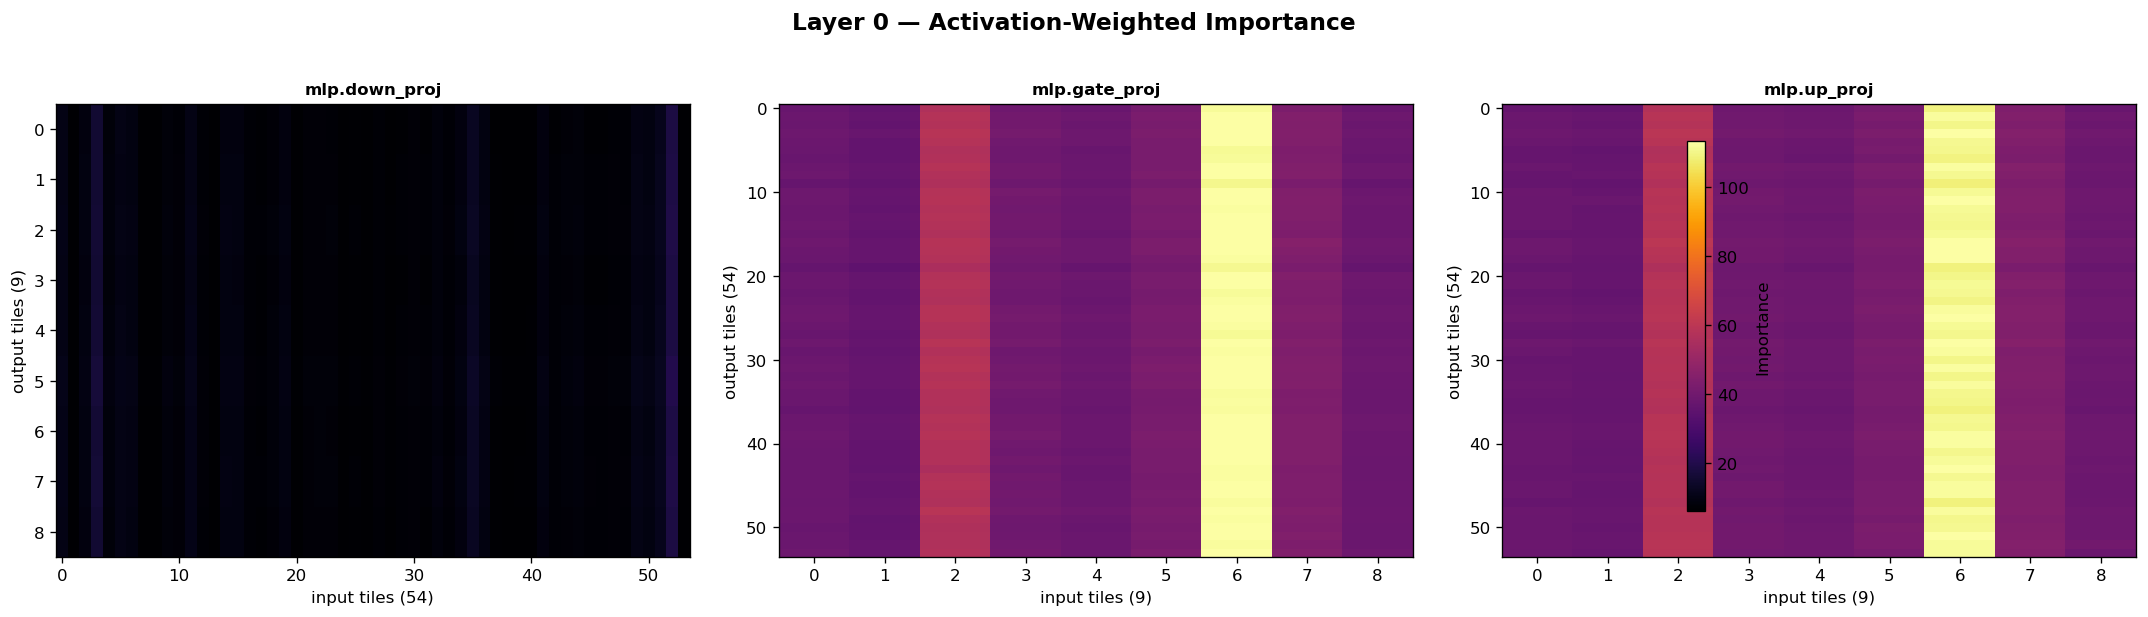

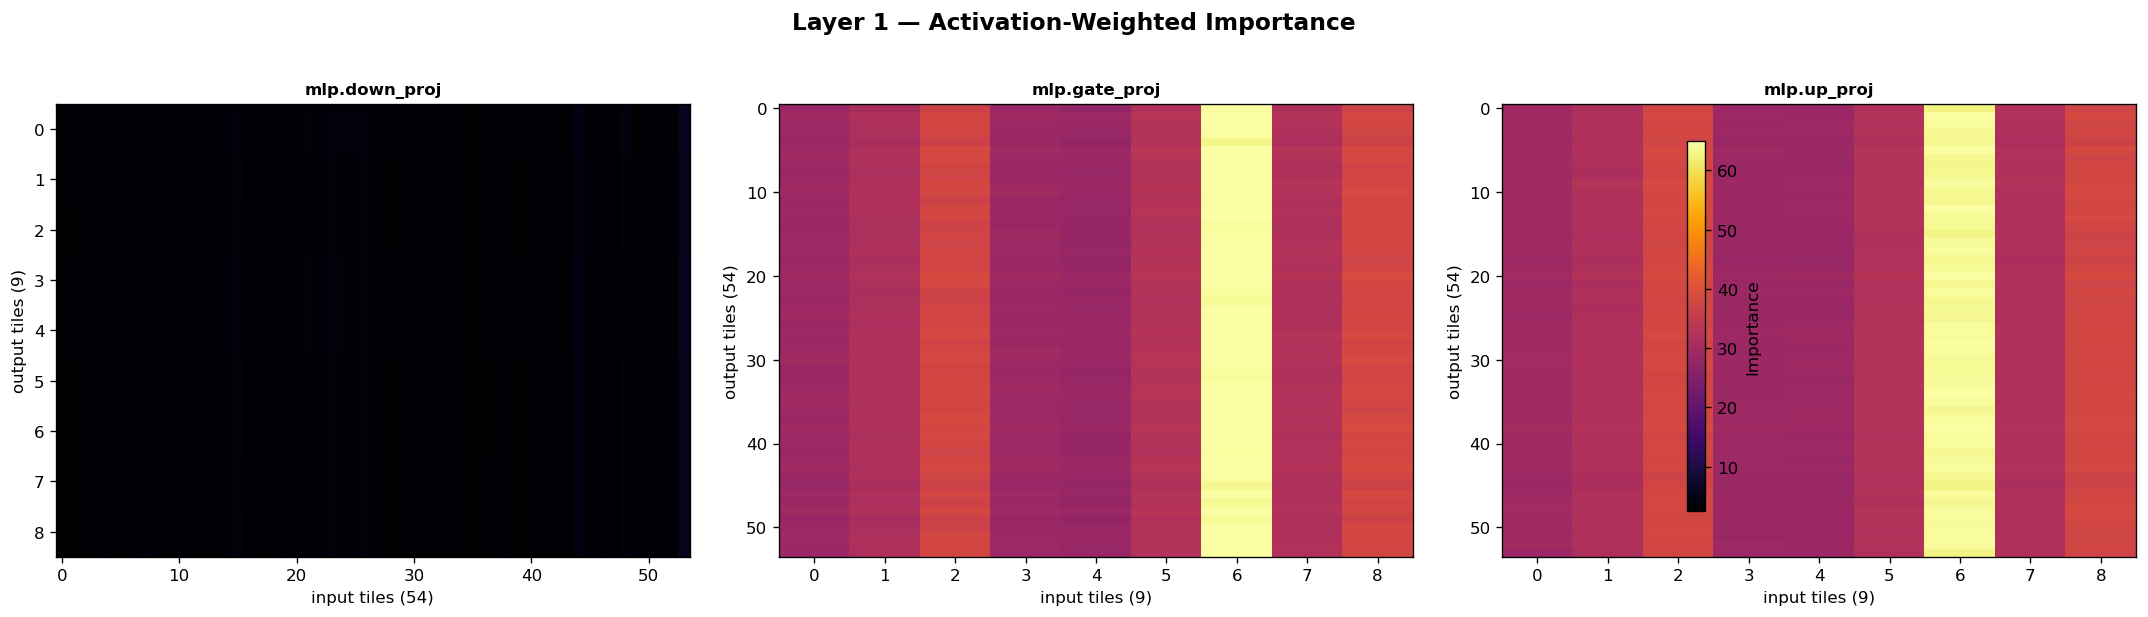

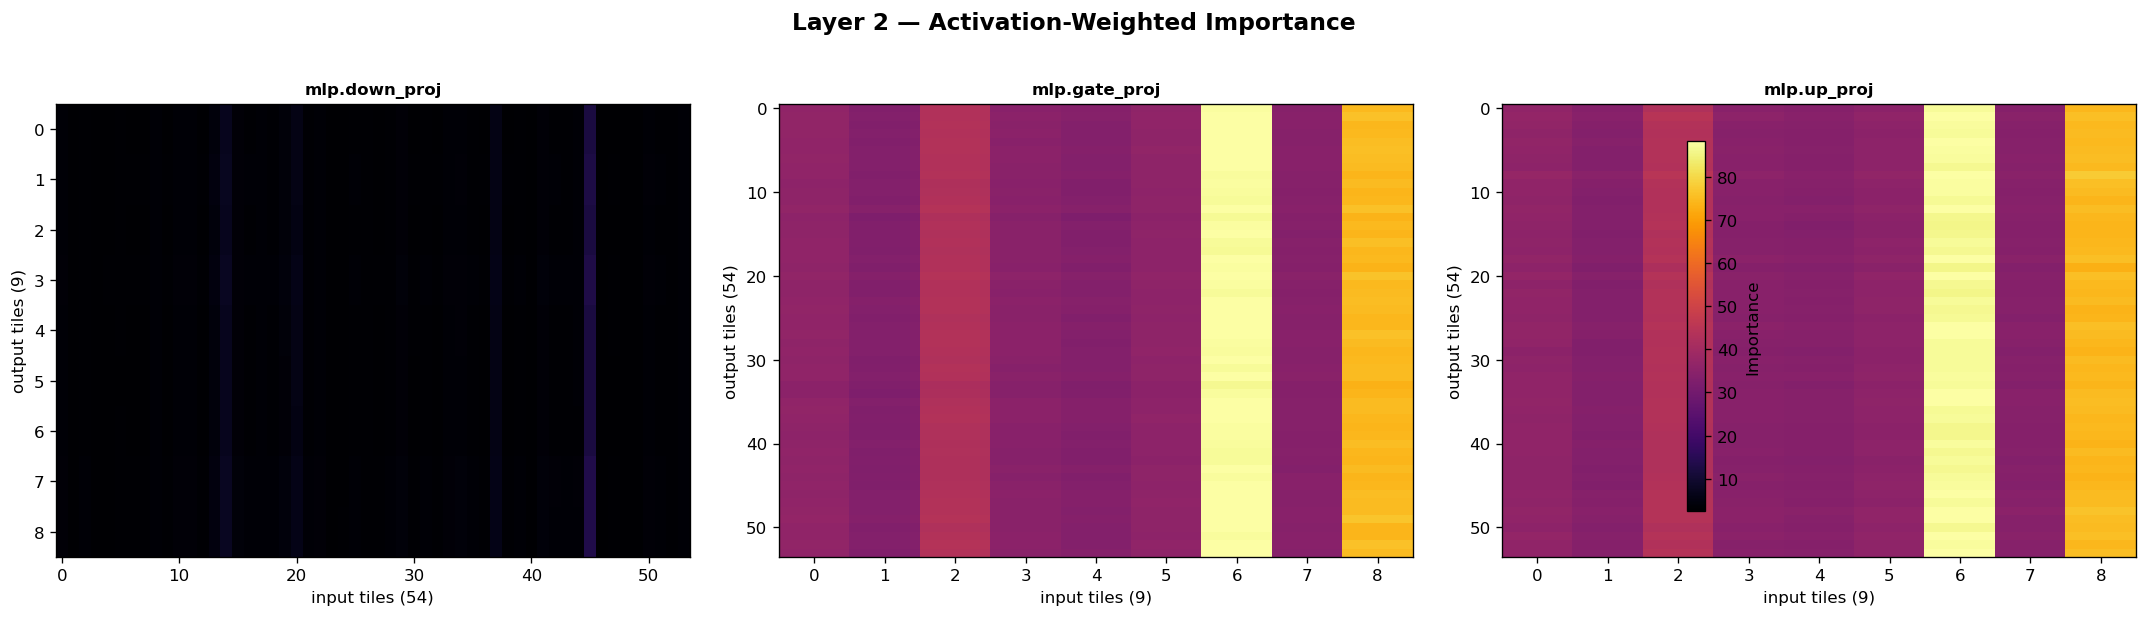

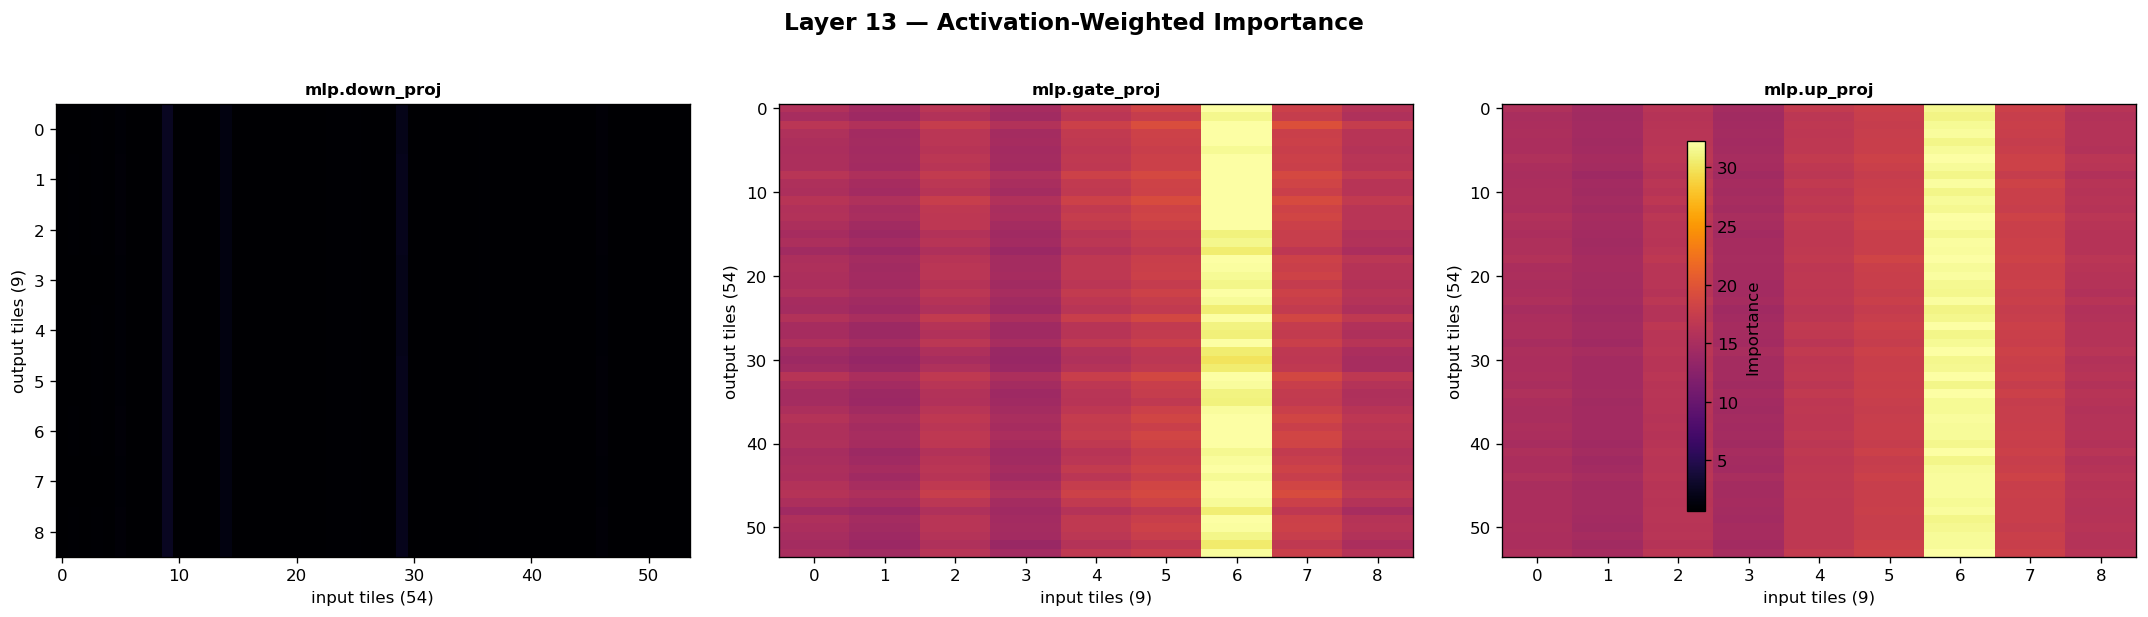

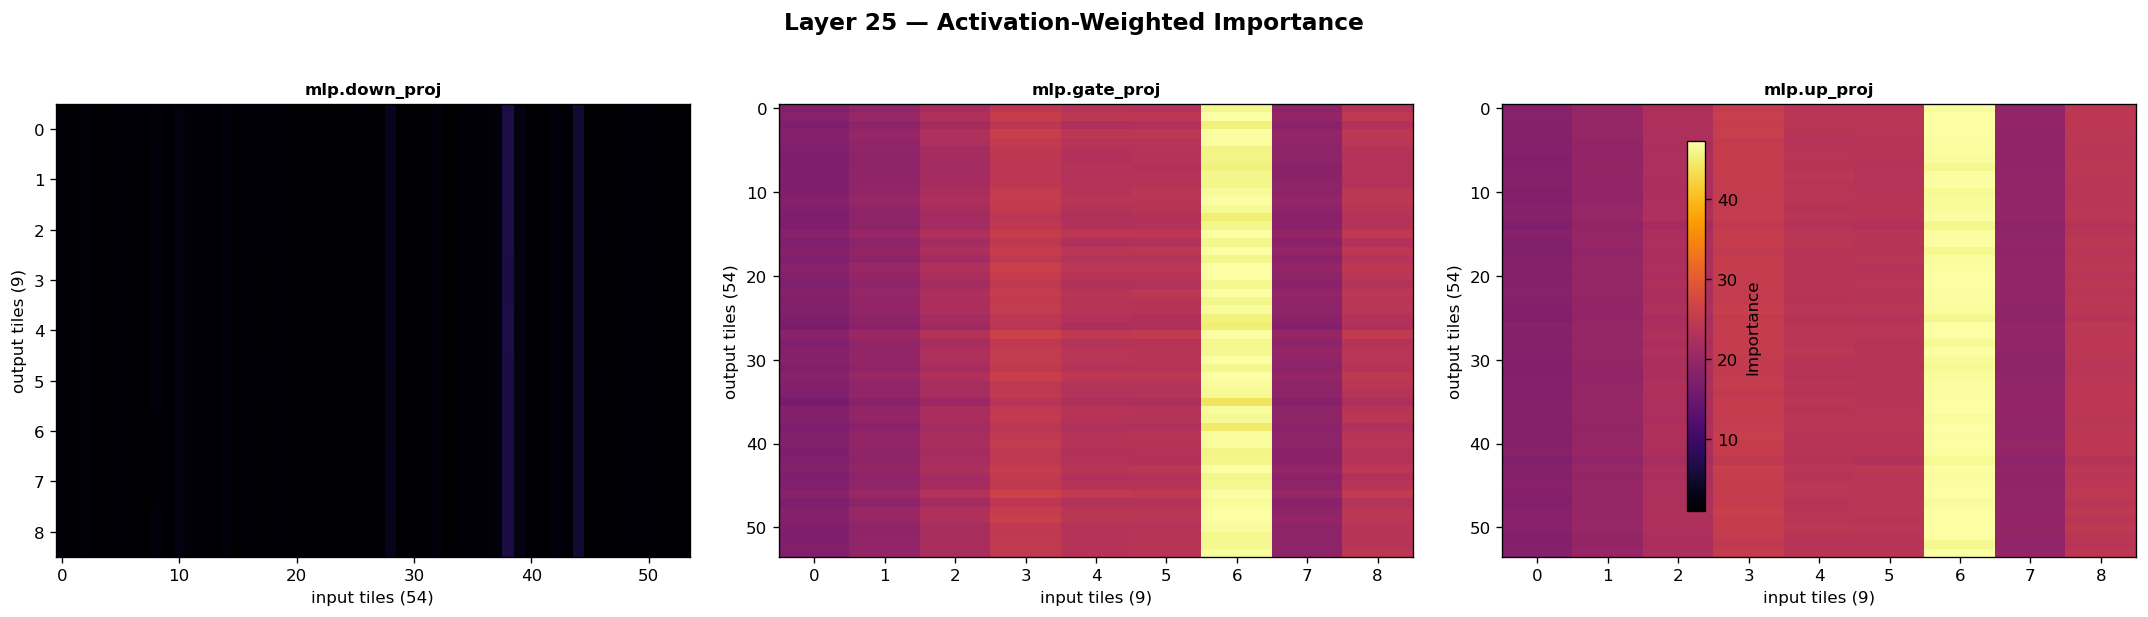

In [10]:
def plot_layer_heatmaps(layer_idx: int, components: dict, title_suffix=""):
    """Plot spatial heatmaps for all weight matrices in a single layer, using a grid layout."""
    n = len(components)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.atleast_2d(axes)
    axes_flat = axes.ravel()
    
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    
    all_vals = np.concatenate([m.ravel() for m in components.values()])
    vmin, vmax = np.percentile(all_vals, [2, 98])
    
    for ax, (comp_name, imp_map) in zip(axes_flat, sorted(components.items())):
        im = ax.imshow(imp_map, aspect="auto", cmap="inferno", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(comp_name, fontsize=10, fontweight="bold")
        ax.set_xlabel(f"input tiles ({imp_map.shape[1]})")
        ax.set_ylabel(f"output tiles ({imp_map.shape[0]})")
    
    fig.suptitle(f"Layer {layer_idx} — Activation-Weighted Importance{title_suffix}", fontsize=14, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes_flat[:n].tolist(), shrink=0.8, label="Importance", pad=0.02)
    plt.tight_layout()
    plt.show()

# Show sample layers using activation-weighted maps
sample_layers = [0, 1, 2, n_layers // 2, n_layers - 1]
for li in sample_layers:
    if li in layer_components_actw:
        plot_layer_heatmaps(li, layer_components_actw[li])

## 5. Full-model overview — all layers, all components (activation-weighted)

Bird's-eye view using activation-weighted importance. Each cell = mean importance of that layer/component.

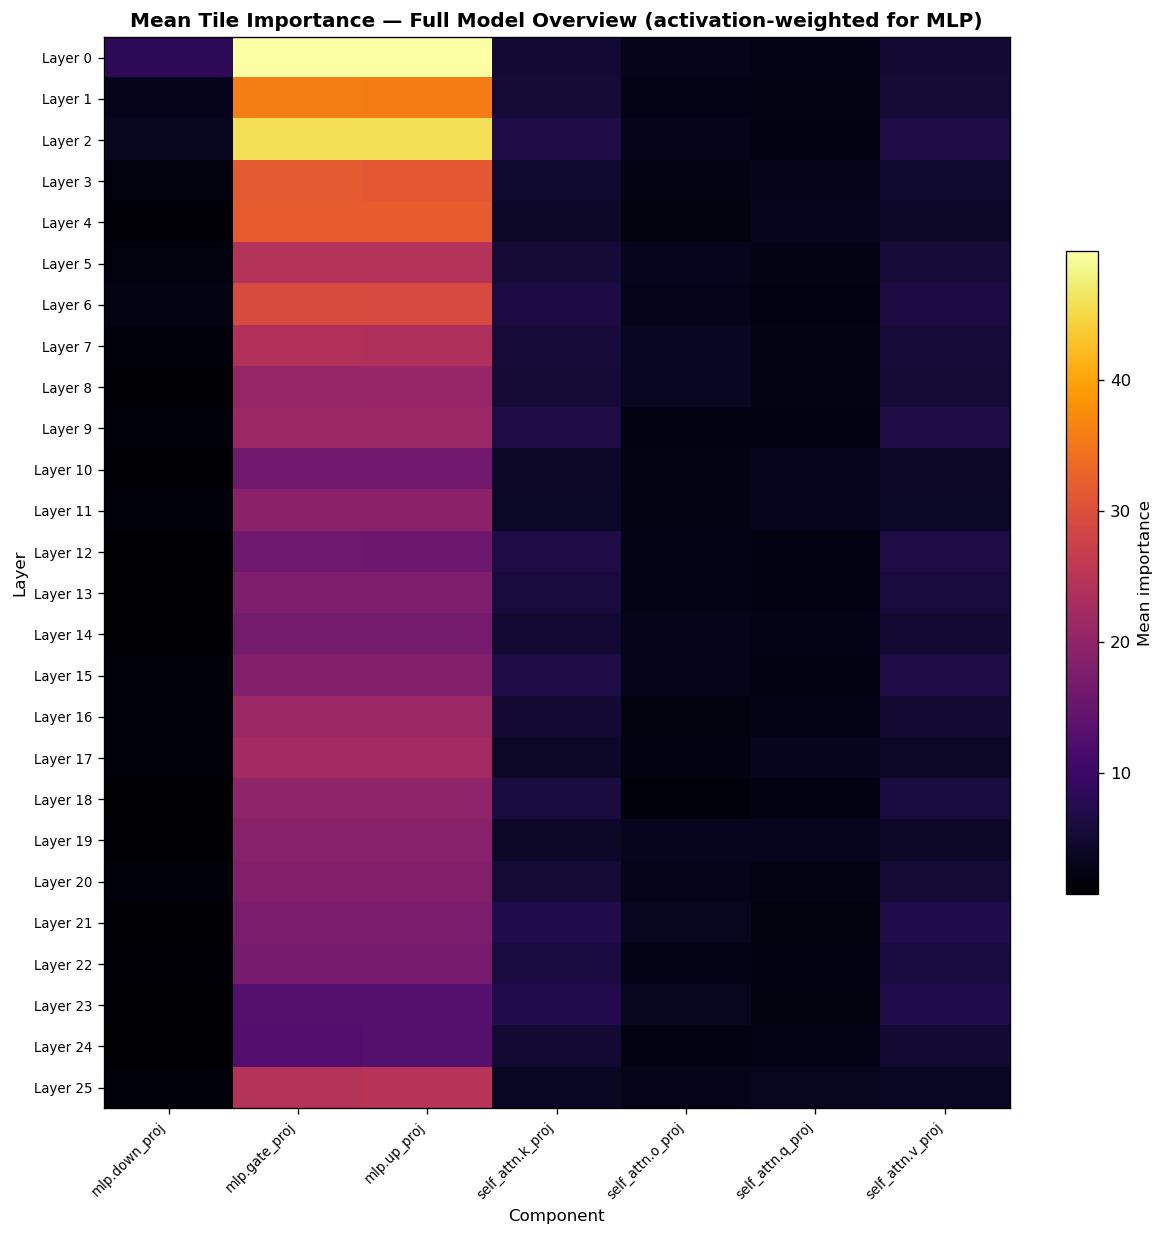

In [11]:
# Build overview using activation-weighted maps (MLP only has actw, attn uses raw)
all_comp_names = sorted(set(c for comps in layer_components.values() for c in comps))
overview = np.zeros((n_layers, len(all_comp_names)))

for li in range(n_layers):
    for ci, comp_name in enumerate(all_comp_names):
        # Use activation-weighted if available (MLP), else raw (attention)
        if comp_name in layer_components_actw.get(li, {}):
            overview[li, ci] = layer_components_actw[li][comp_name].mean()
        elif comp_name in layer_components[li]:
            overview[li, ci] = layer_components[li][comp_name].mean()

fig, ax = plt.subplots(figsize=(max(8, len(all_comp_names) * 1.5), max(8, n_layers * 0.4)))
im = ax.imshow(overview, aspect="auto", cmap="inferno", interpolation="nearest")

ax.set_xticks(range(len(all_comp_names)))
ax.set_xticklabels(all_comp_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_layers))
ax.set_yticklabels([f"Layer {i}" for i in range(n_layers)], fontsize=8)
ax.set_xlabel("Component")
ax.set_ylabel("Layer")
ax.set_title("Mean Tile Importance — Full Model Overview (activation-weighted for MLP)", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.6, label="Mean importance")
plt.tight_layout()
plt.show()

## 6. Pruning candidate map (activation-weighted, MLP only)

Now using activation-weighted importance for pruning decisions.

In [12]:
PRUNE_RATIO = 0.30

def compute_global_threshold(maps: dict, ratio: float) -> float:
    all_scores = np.concatenate([m.ravel() for m in maps.values()])
    return float(np.percentile(all_scores, ratio * 100))

# Activation-weighted threshold
threshold_actw = compute_global_threshold(importance_maps_actw_norm, PRUNE_RATIO)
# Frobenius threshold (kept for comparison eval)
threshold_frob = compute_global_threshold(importance_maps_mlp_norm, PRUNE_RATIO)

print(f"Pruning ratio: {PRUNE_RATIO*100:.0f}%")
print(f"  Activation-weighted threshold: {threshold_actw:.4f}")
print(f"  Frobenius threshold:           {threshold_frob:.4f}")
print()

for label, maps in [("Activation-weighted", importance_maps_actw_norm), ("Frobenius", importance_maps_mlp_norm)]:
    thresh = compute_global_threshold(maps, PRUNE_RATIO)
    total = sum(m.size for m in maps.values())
    pruned = sum((m < thresh).sum() for m in maps.values())
    print(f"{label}: {pruned}/{total} tiles pruned ({pruned/total*100:.1f}%)")
    for comp_type in config.PRUNE_TARGETS_PATTERNS:
        tiles = np.concatenate([m.ravel() for name, m in maps.items() if comp_type in name])
        pct = (tiles < thresh).mean() * 100
        print(f"    {comp_type}: {pct:.1f}%")

# Use activation-weighted as the primary threshold for visualizations
threshold = threshold_actw

Pruning ratio: 30%
  Activation-weighted threshold: -0.5027
  Frobenius threshold:           -0.6309

Activation-weighted: 11373/37908 tiles pruned (30.0%)
    gate_proj: 30.4%
    up_proj: 30.6%
    down_proj: 29.0%
Frobenius: 11373/37908 tiles pruned (30.0%)
    gate_proj: 26.8%
    up_proj: 28.6%
    down_proj: 34.6%


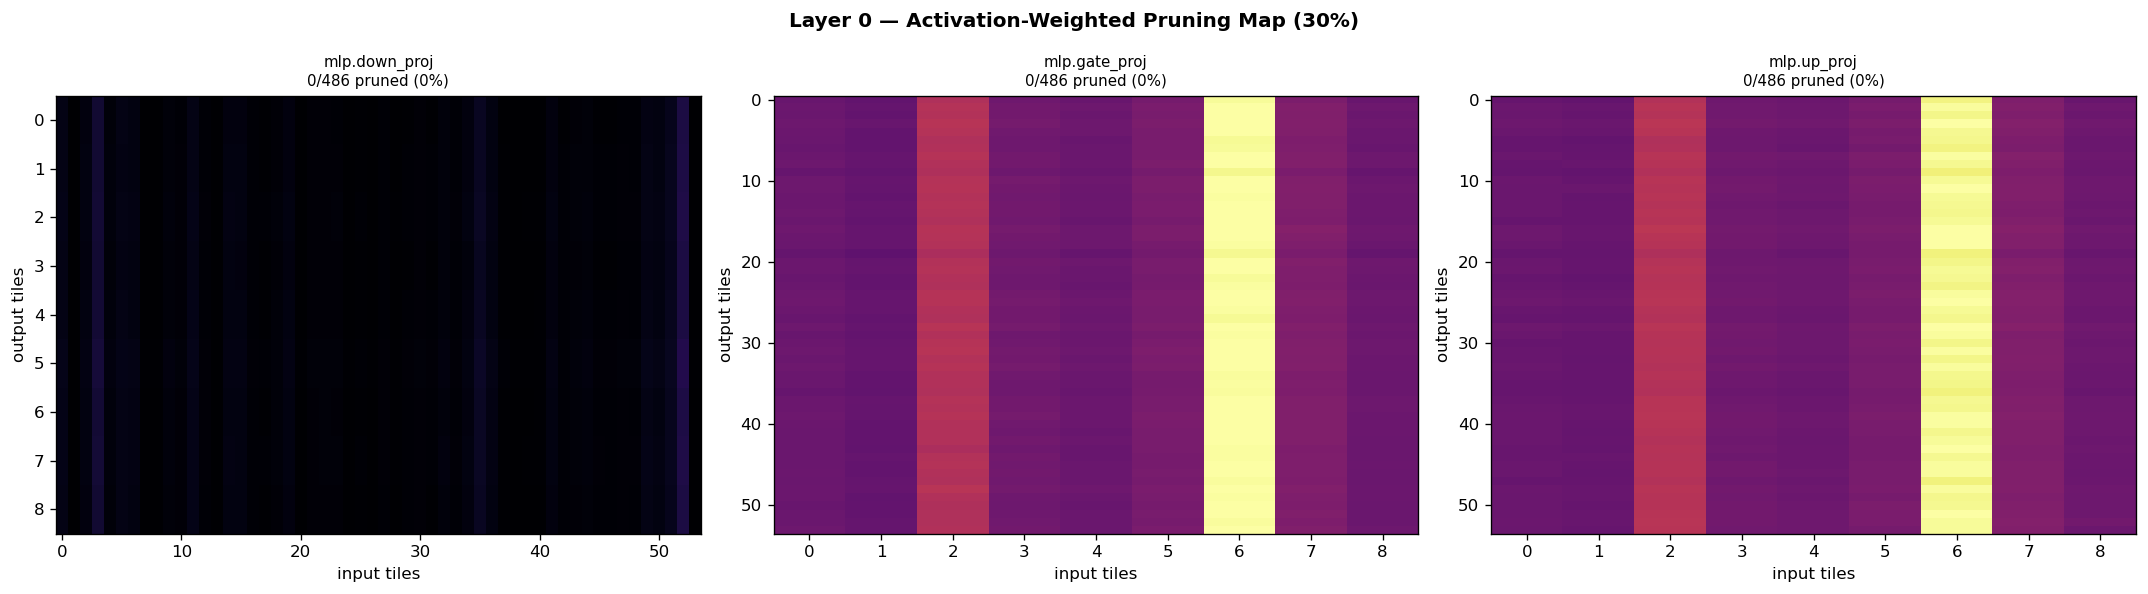

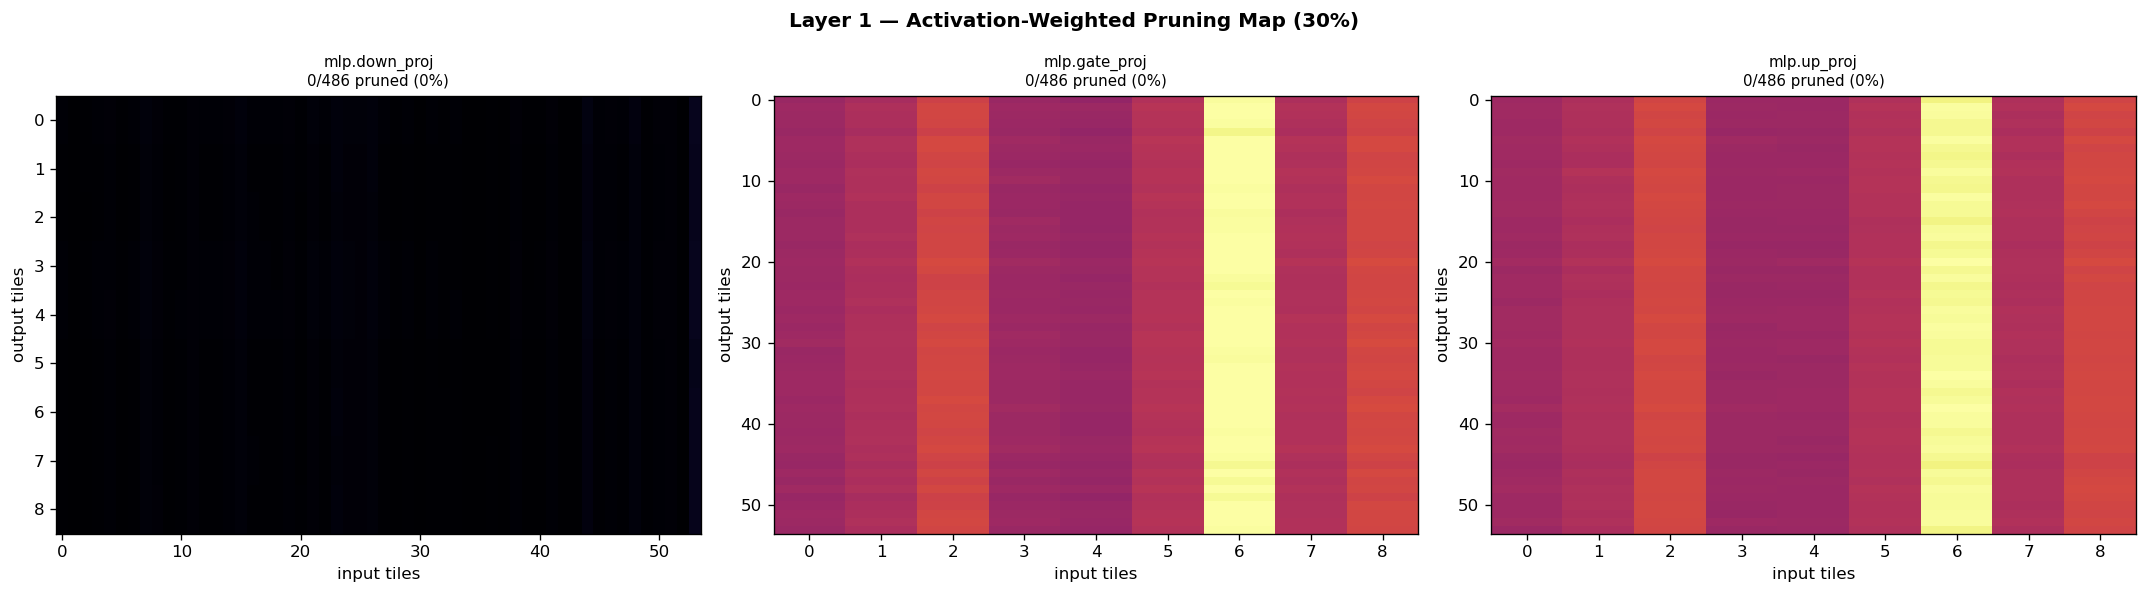

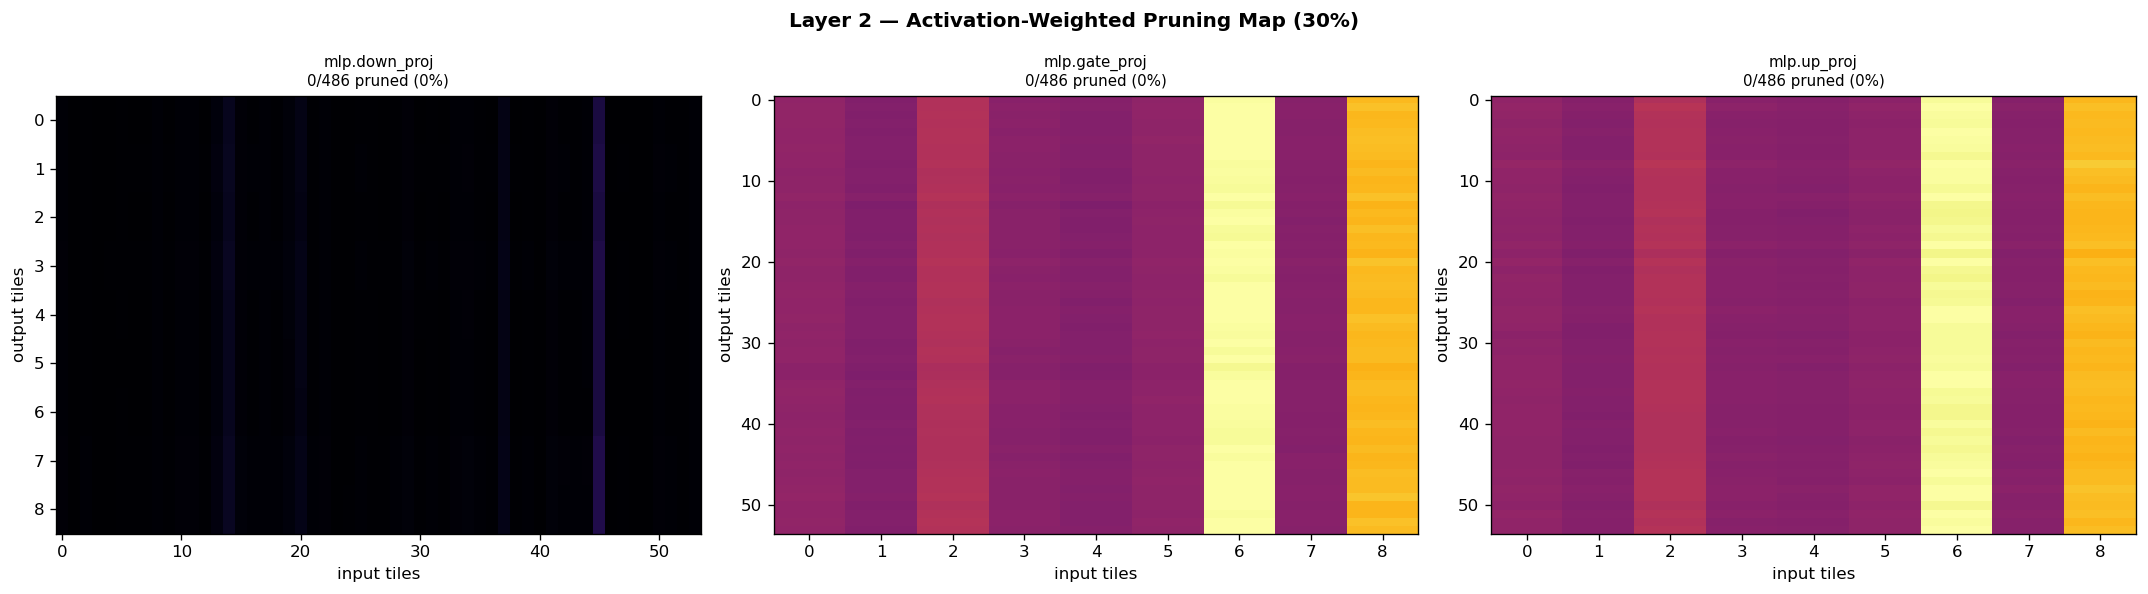

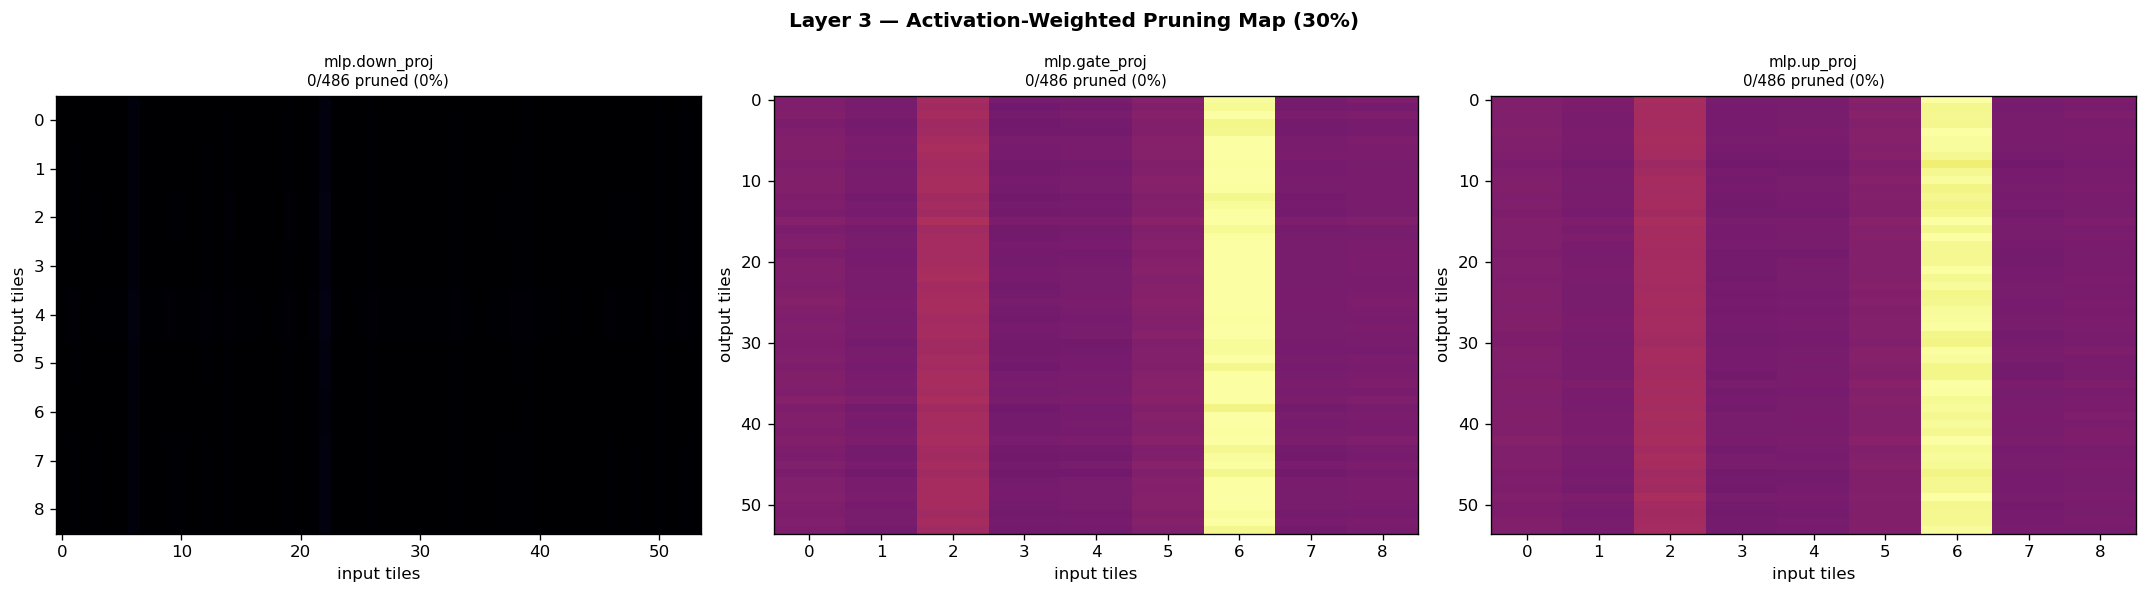

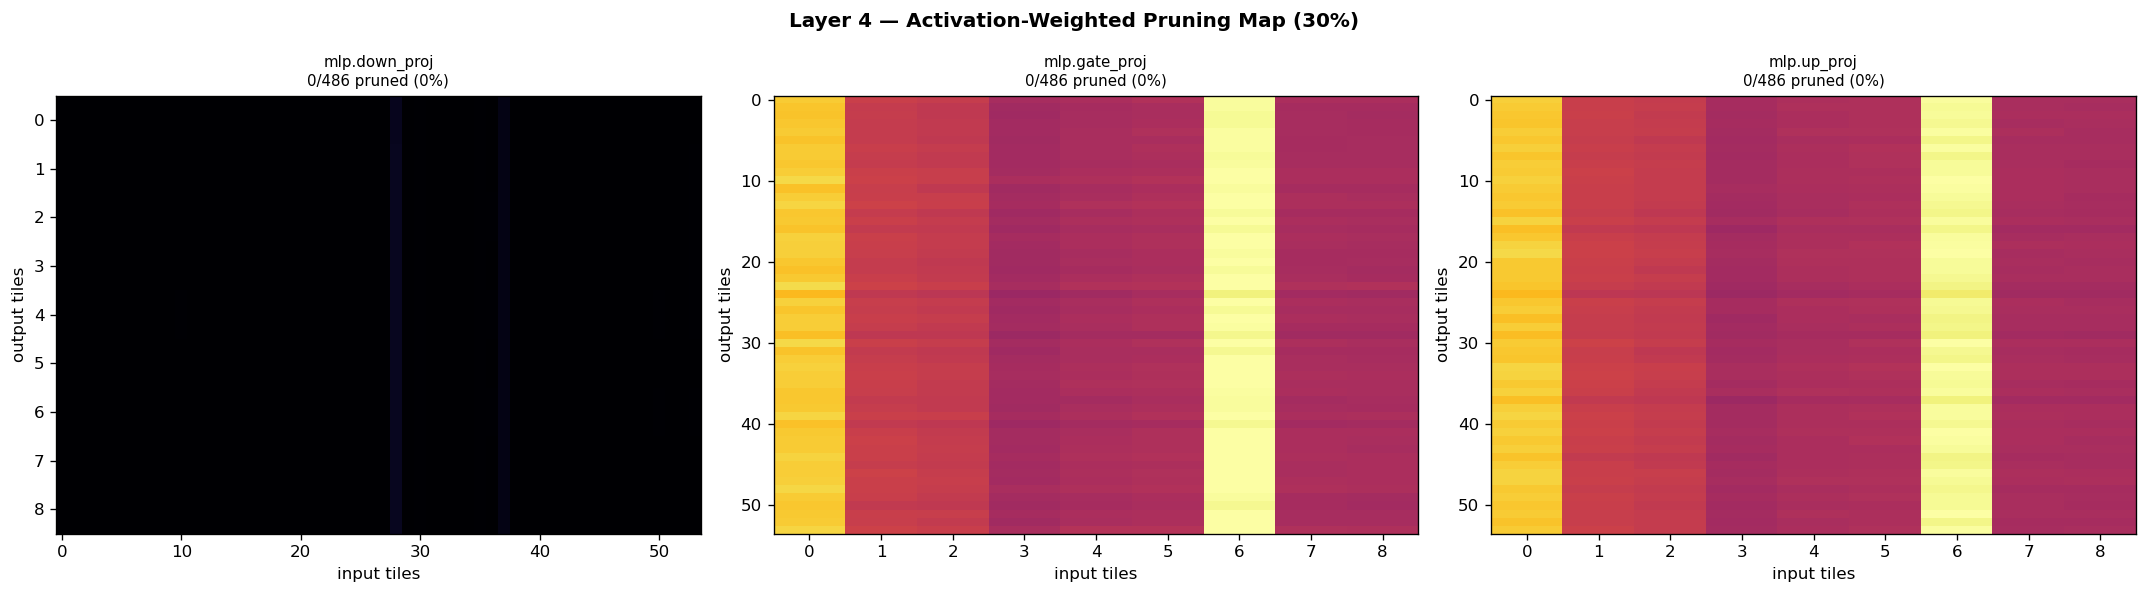

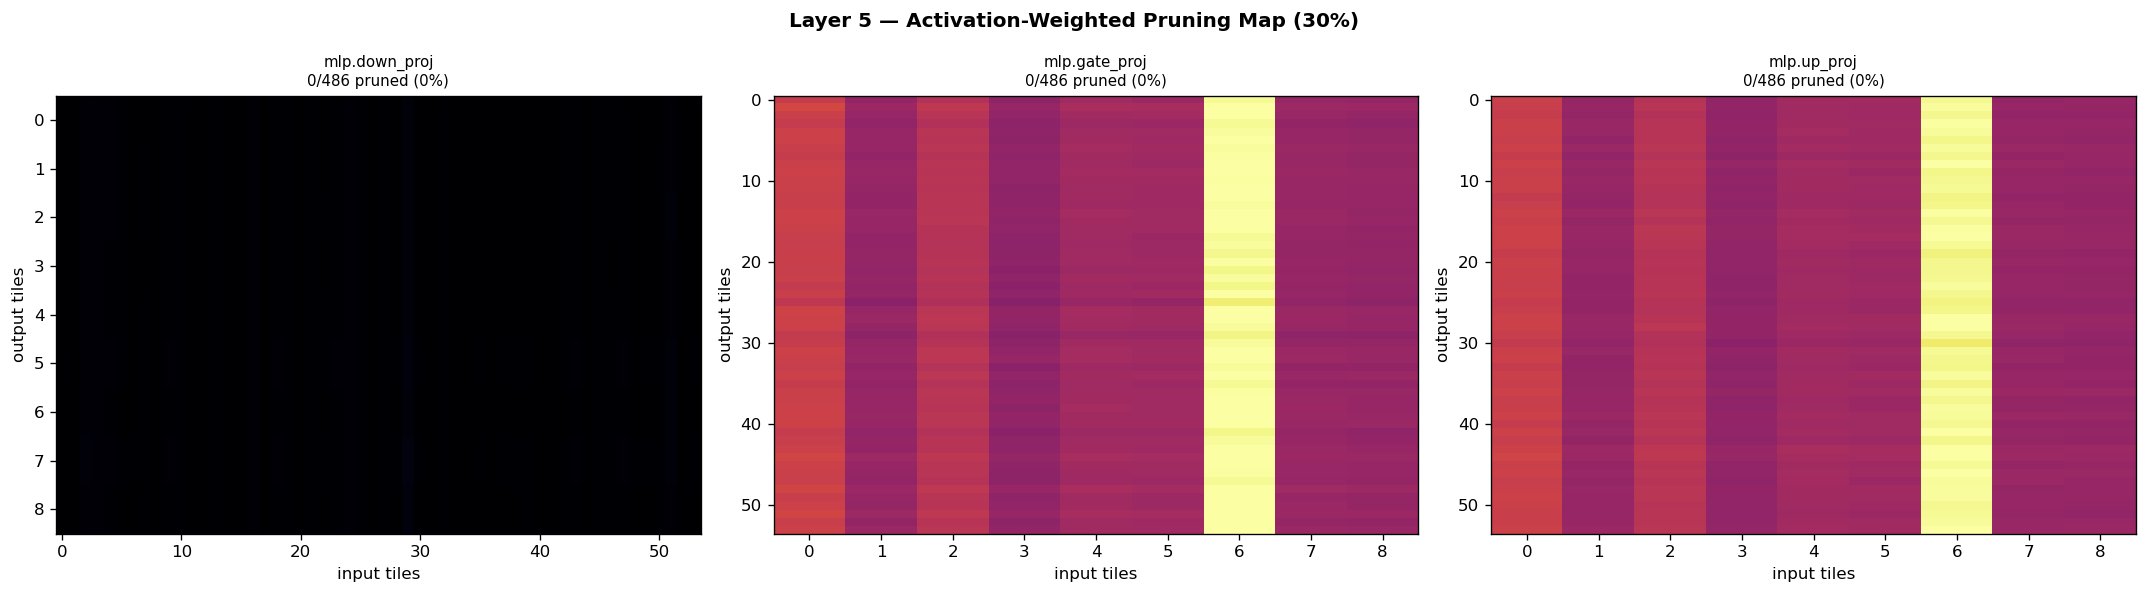

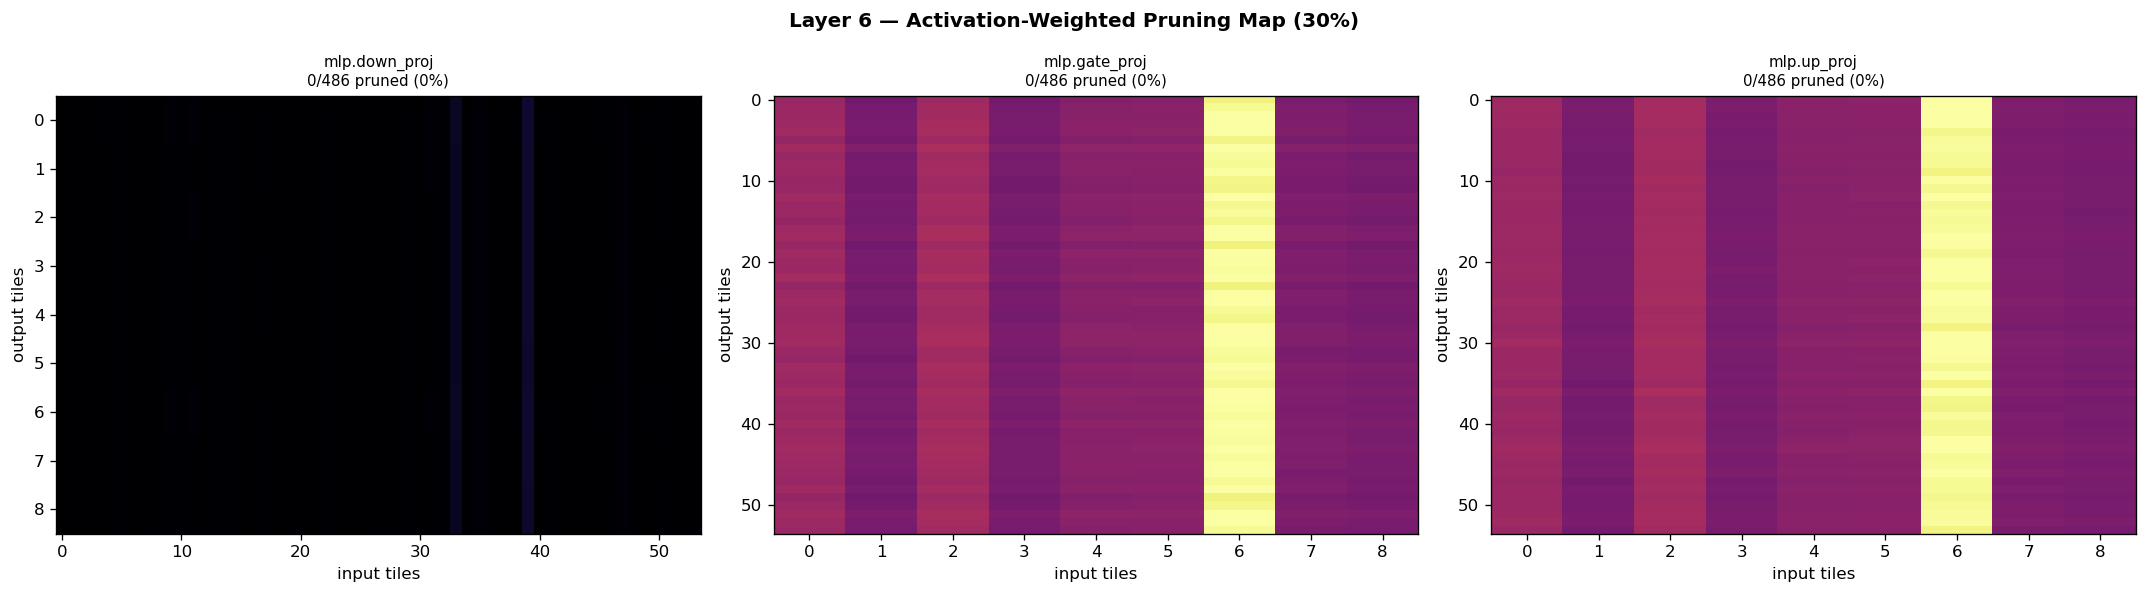

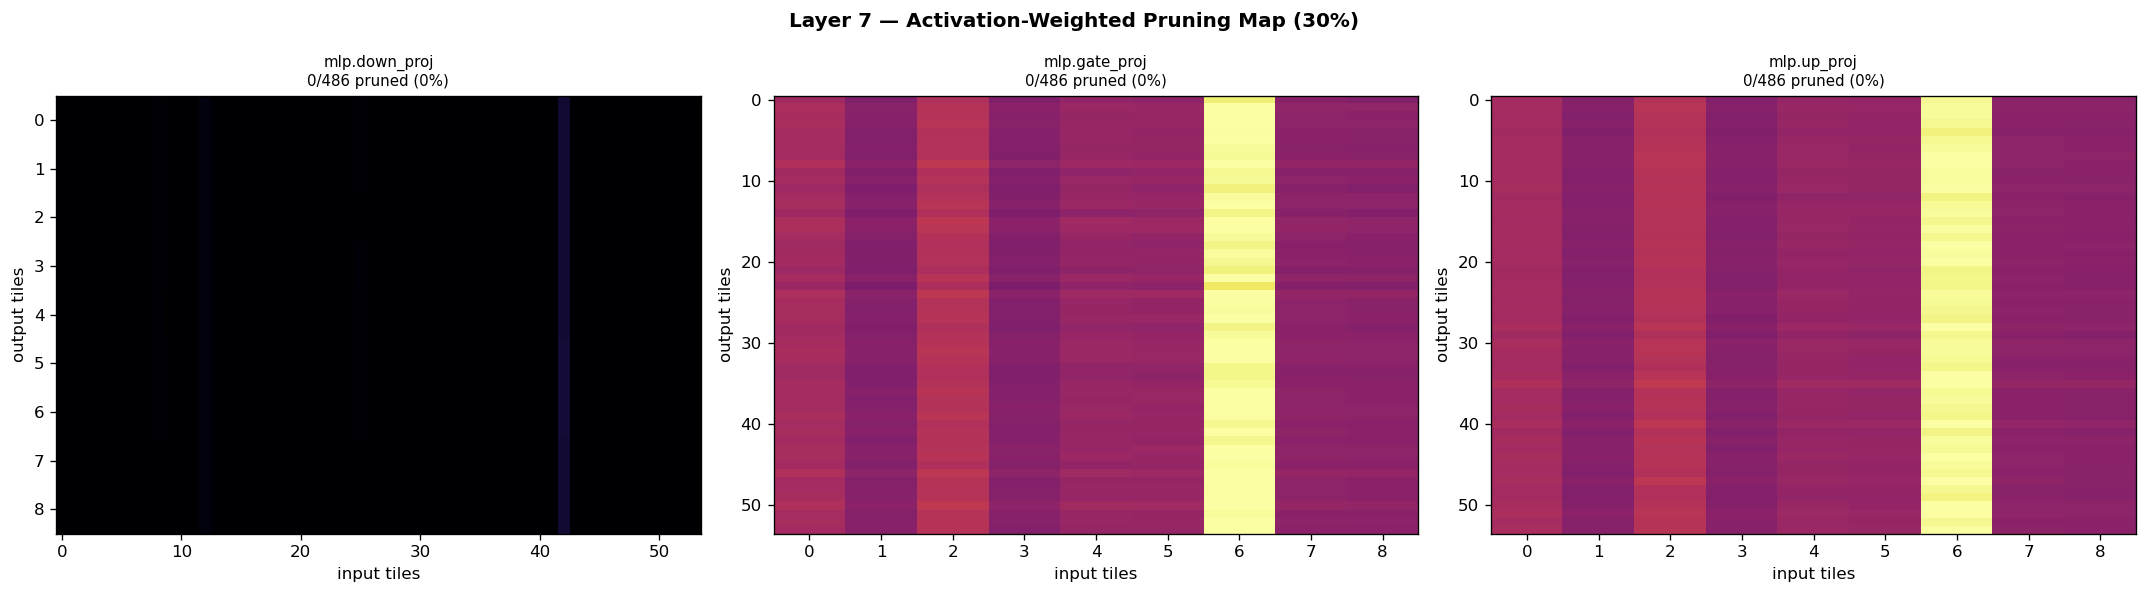

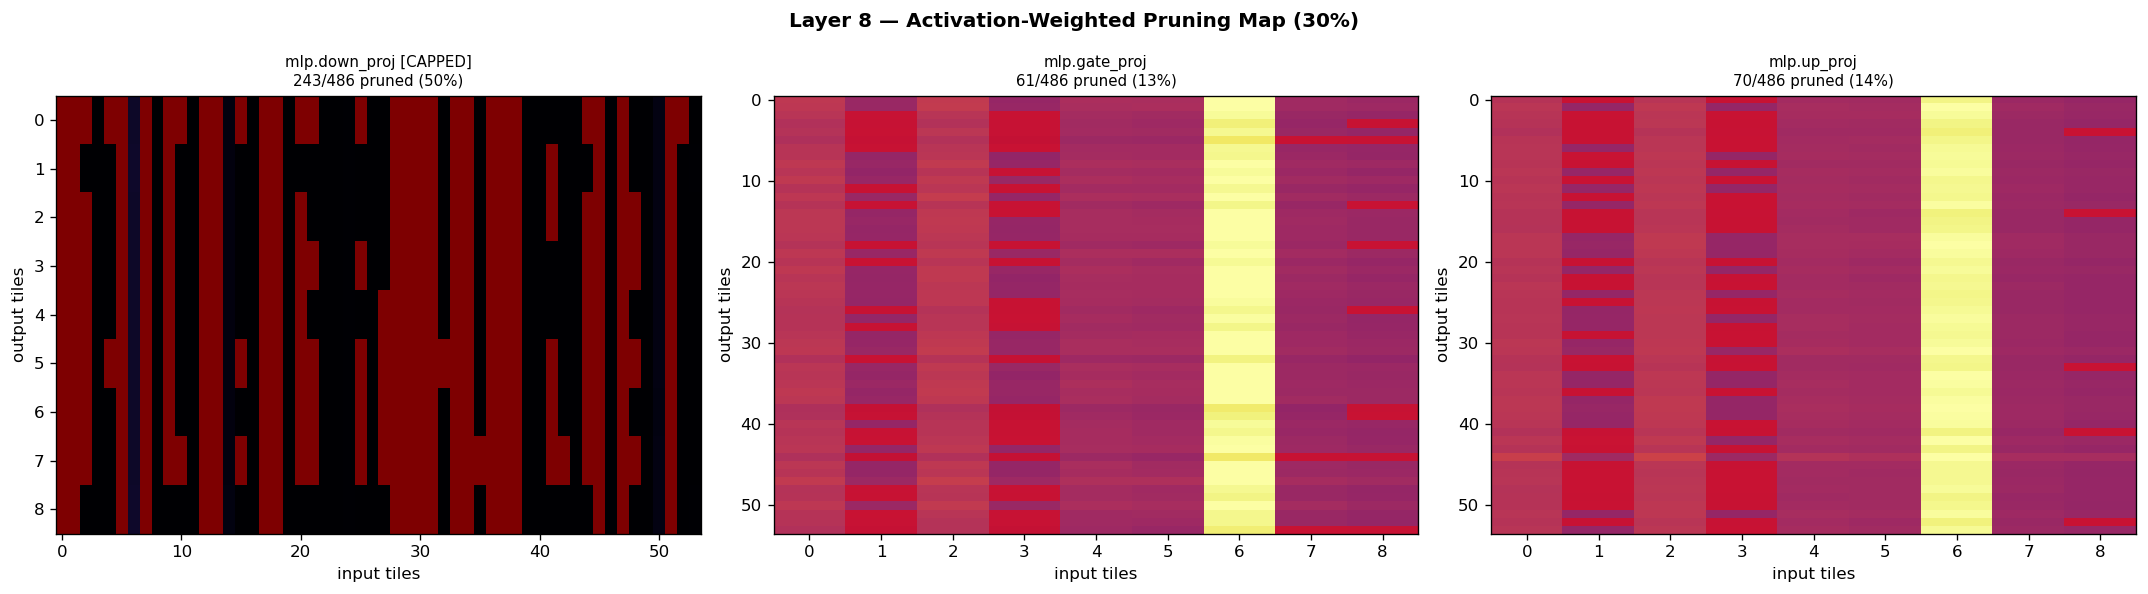

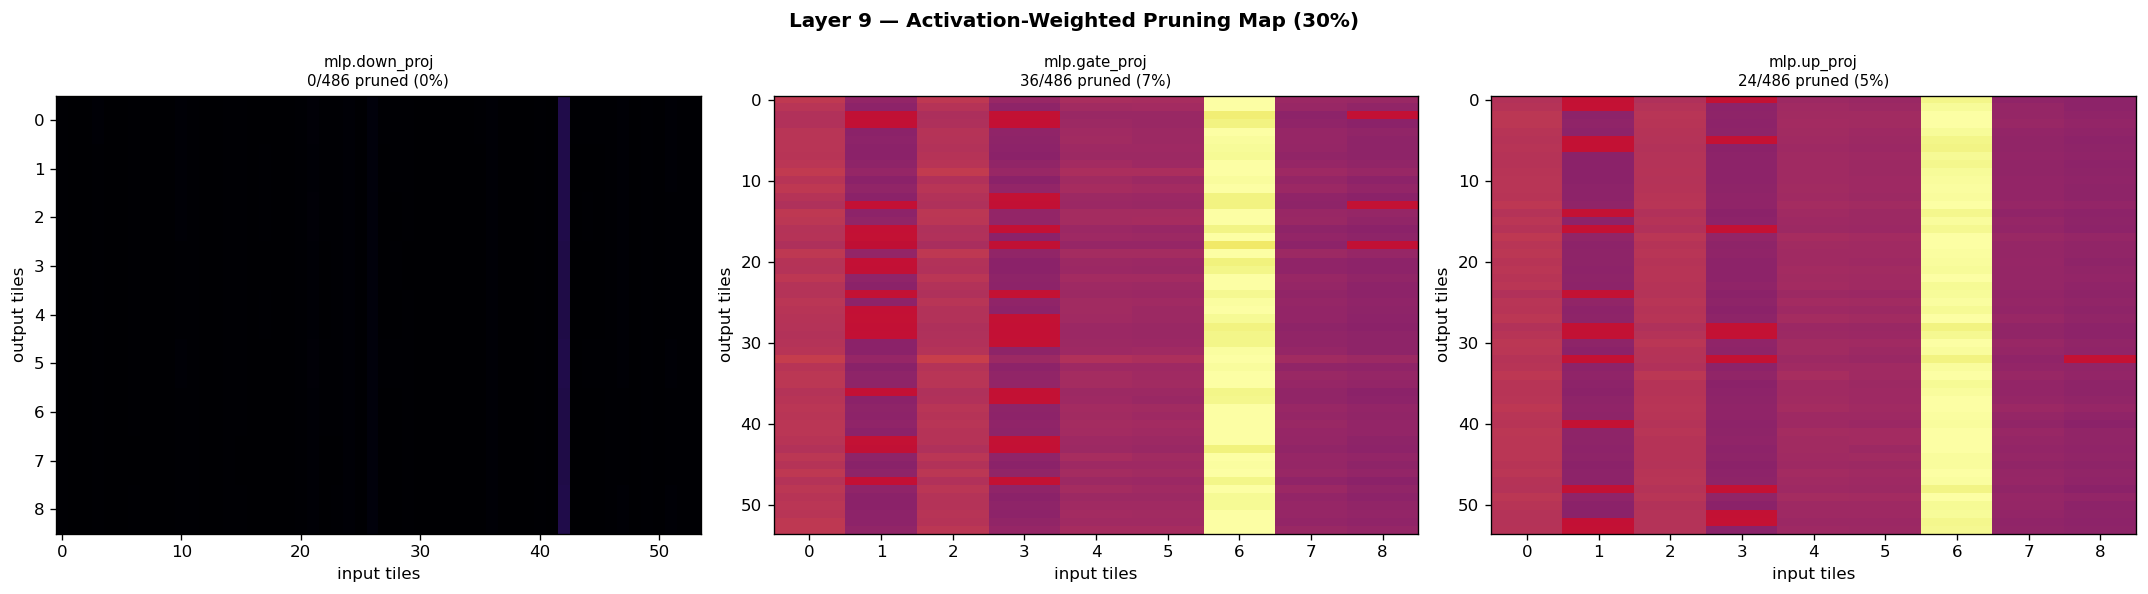

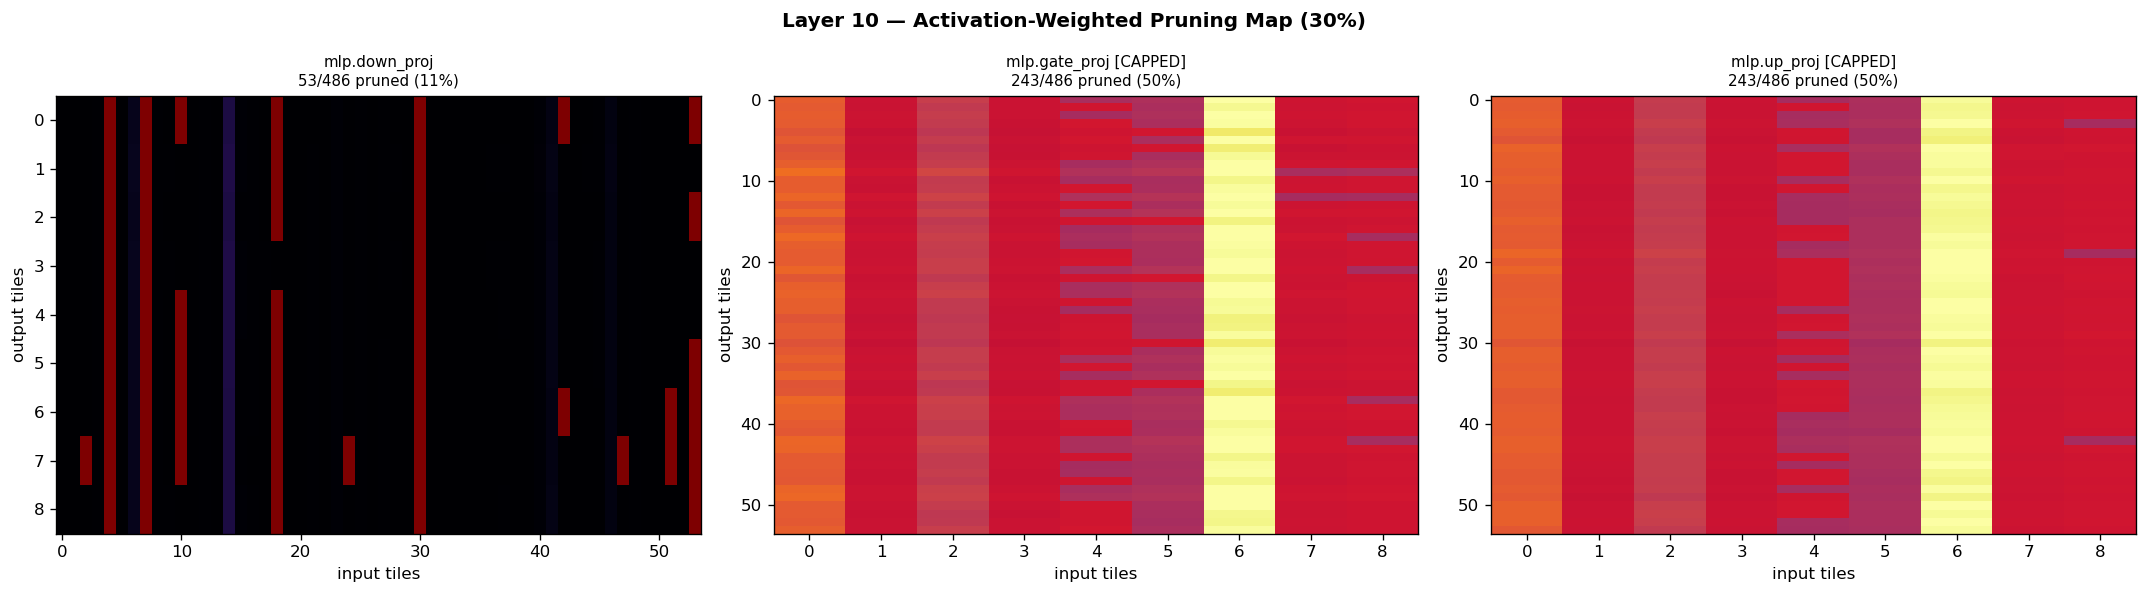

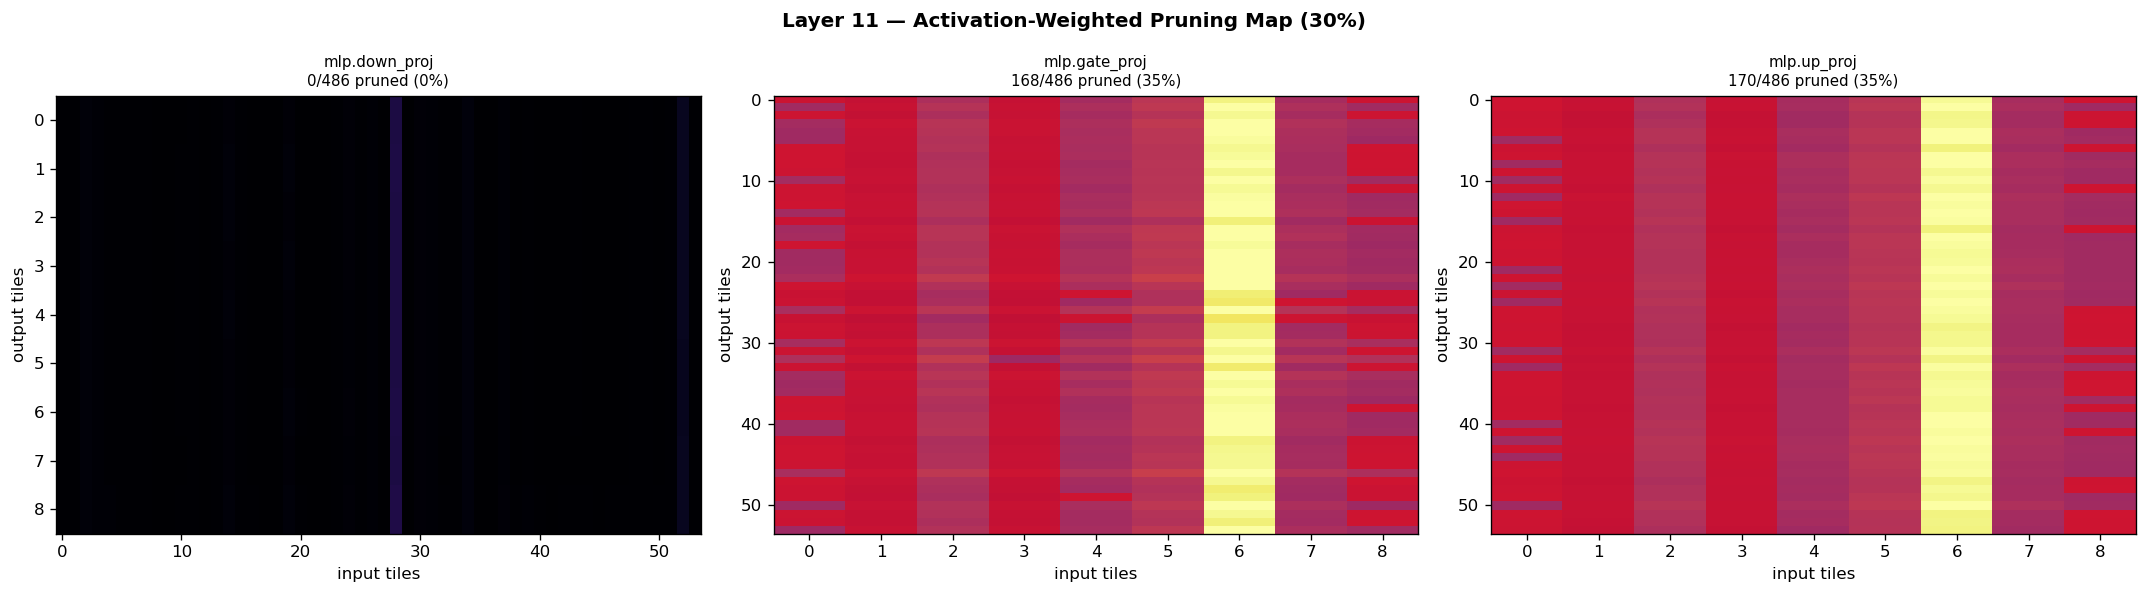

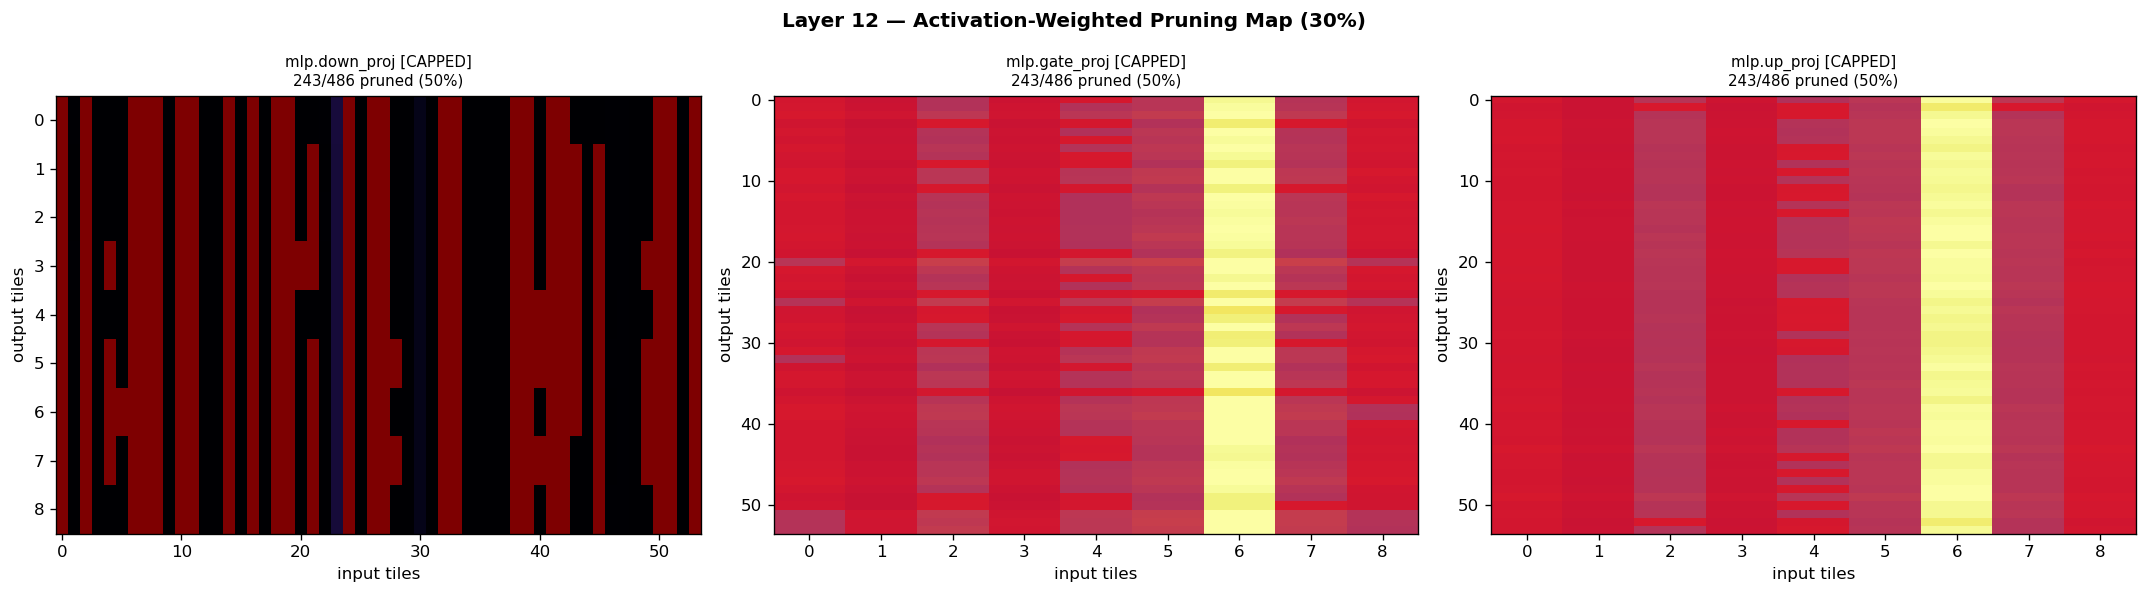

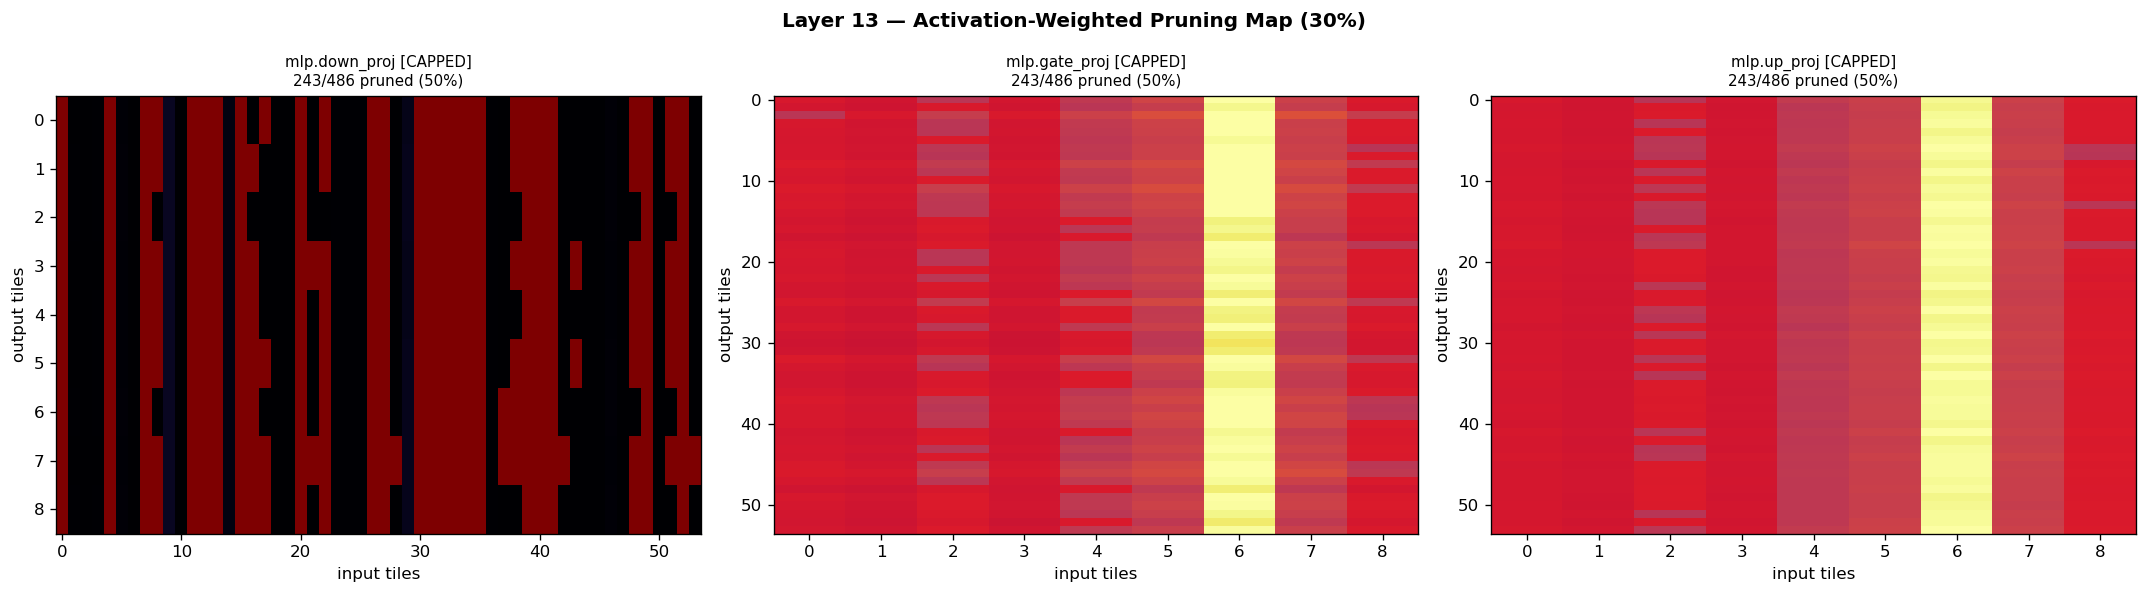

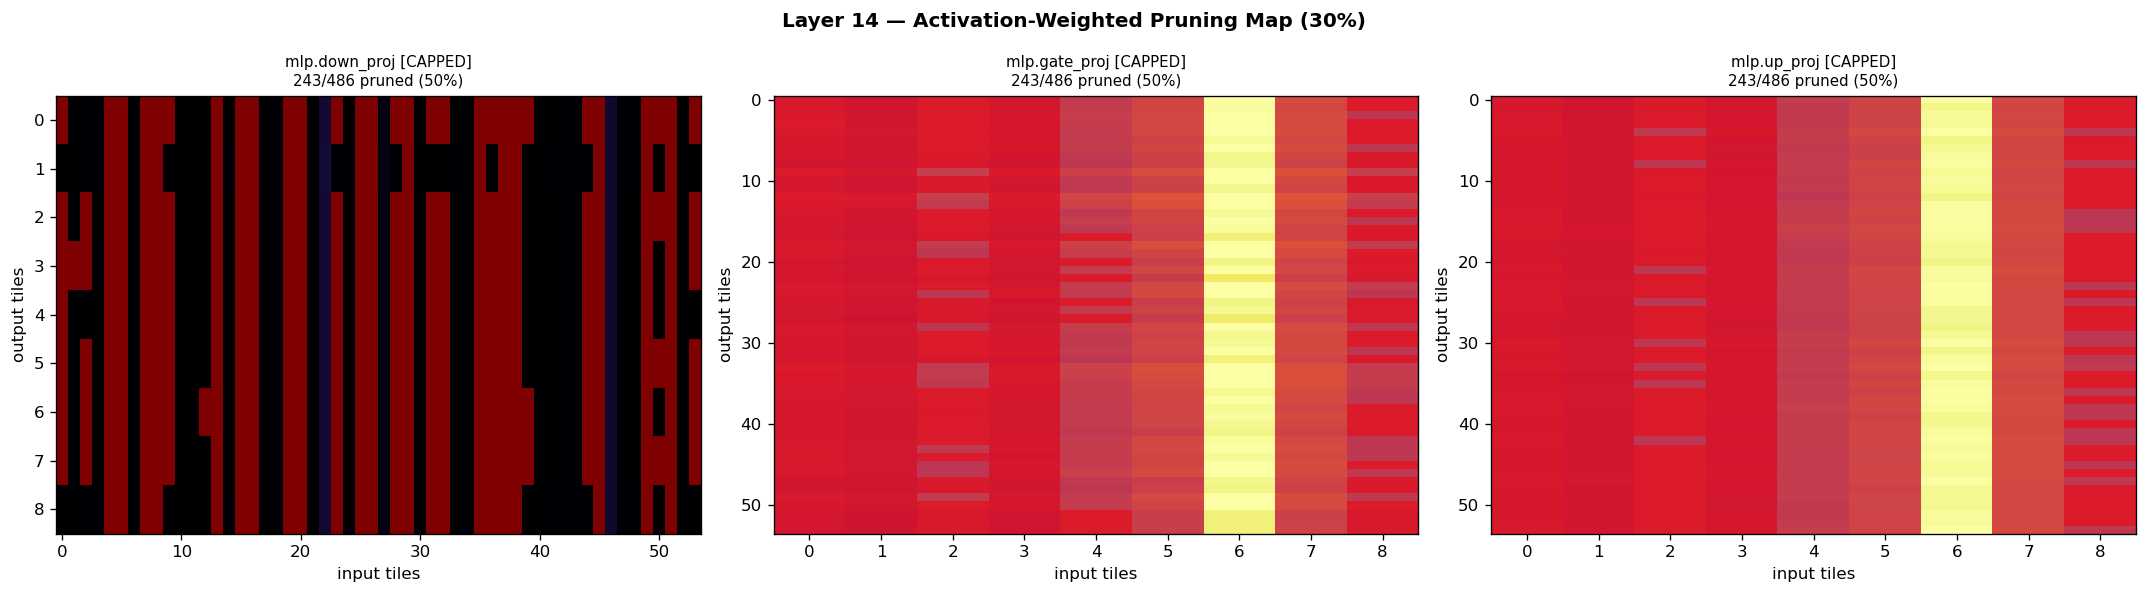

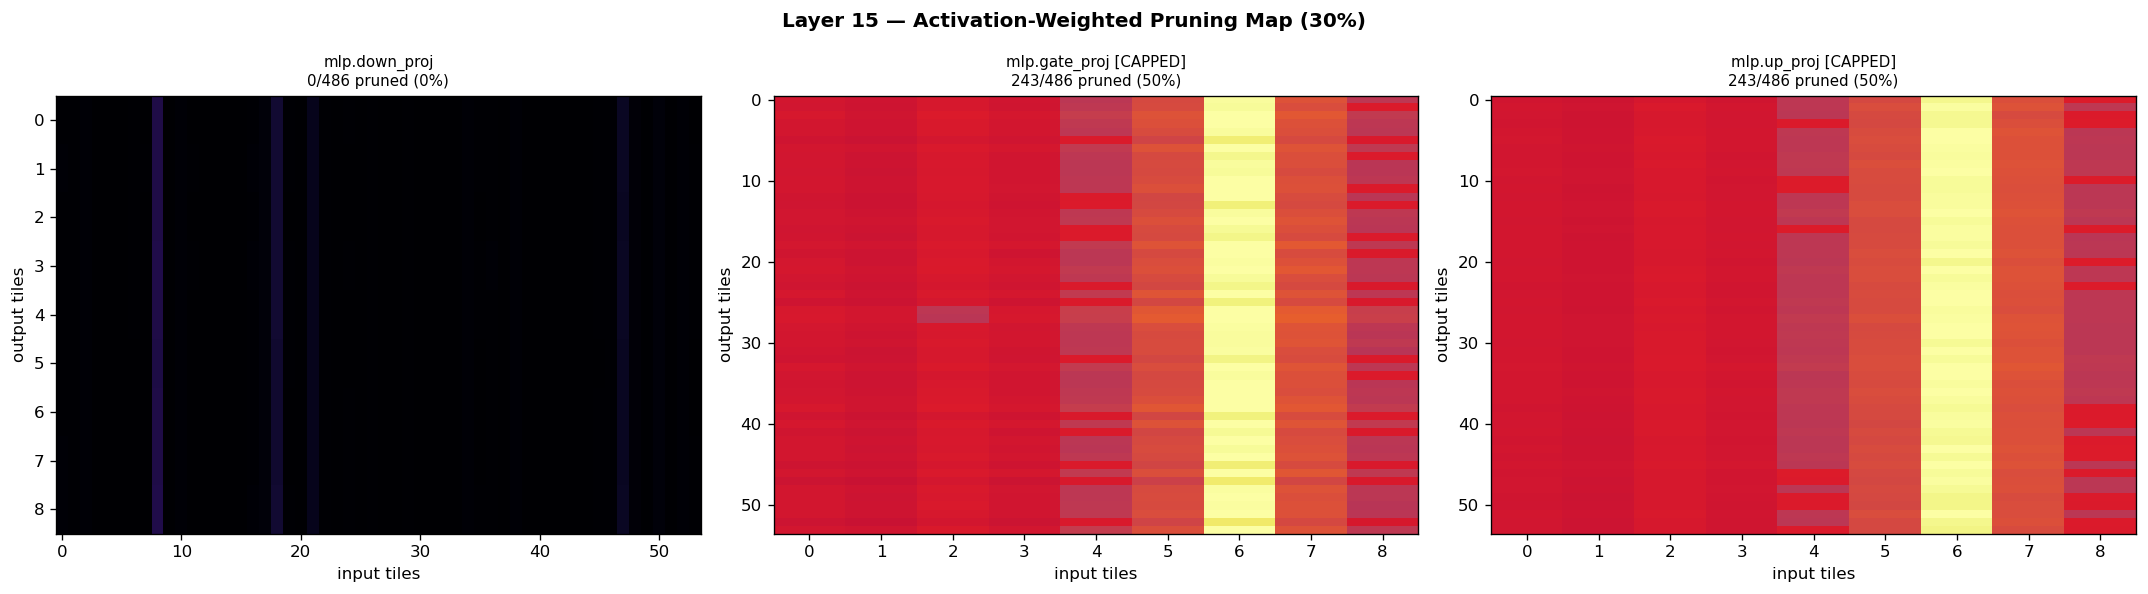

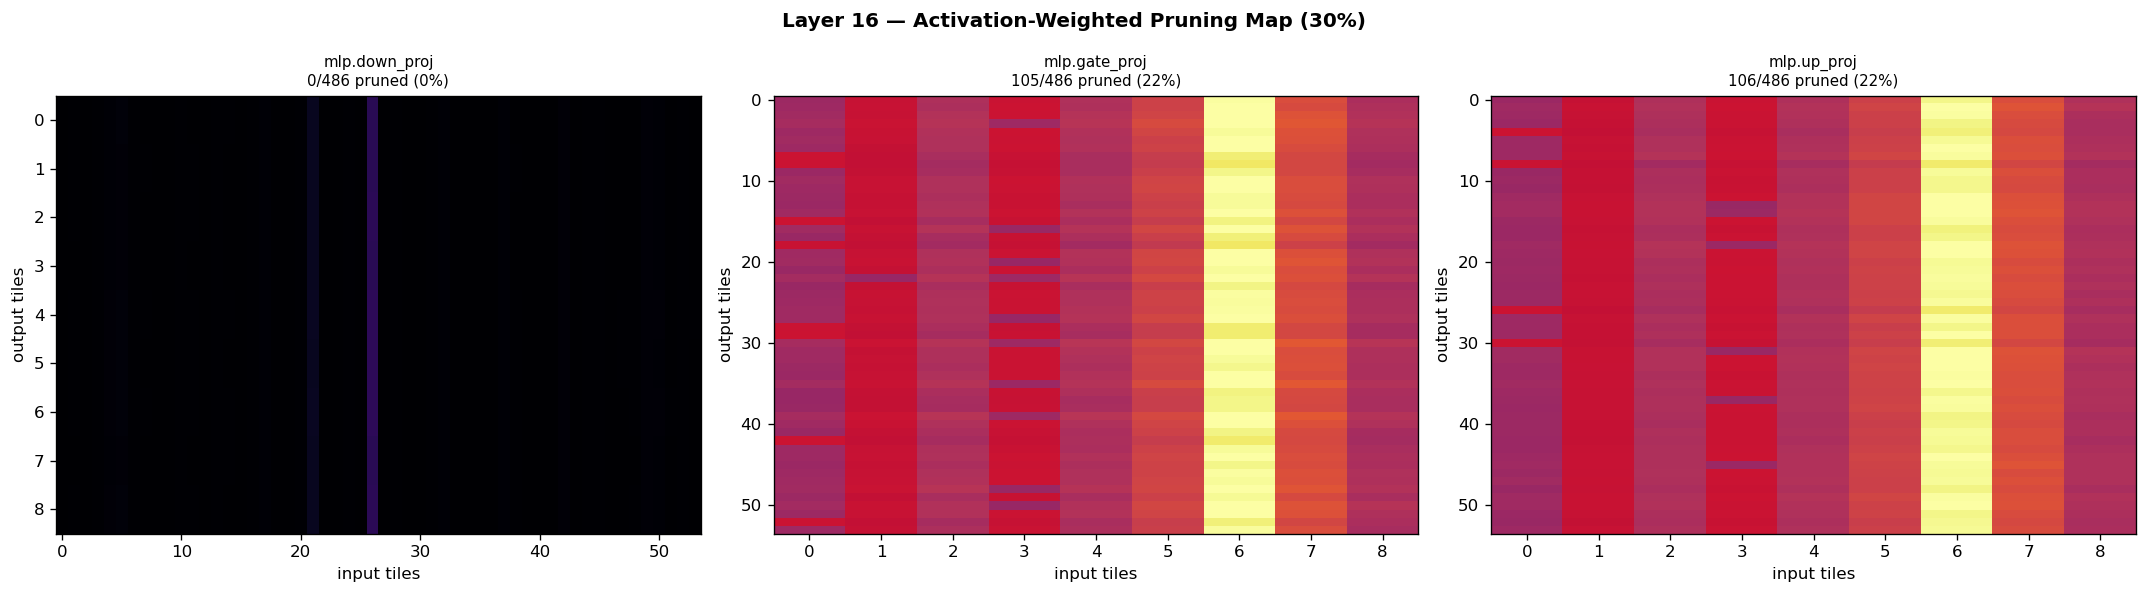

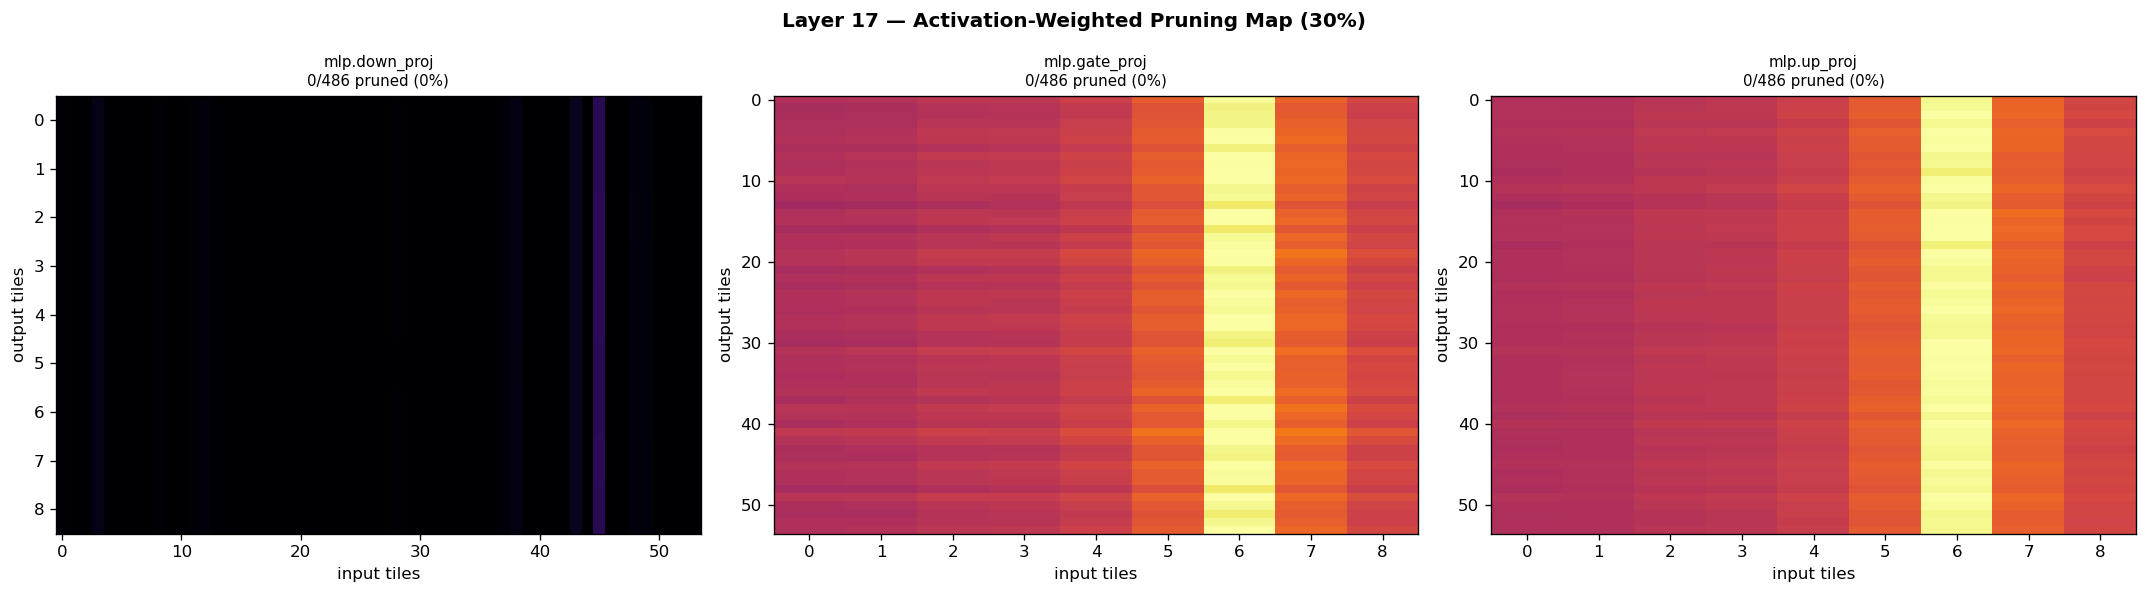

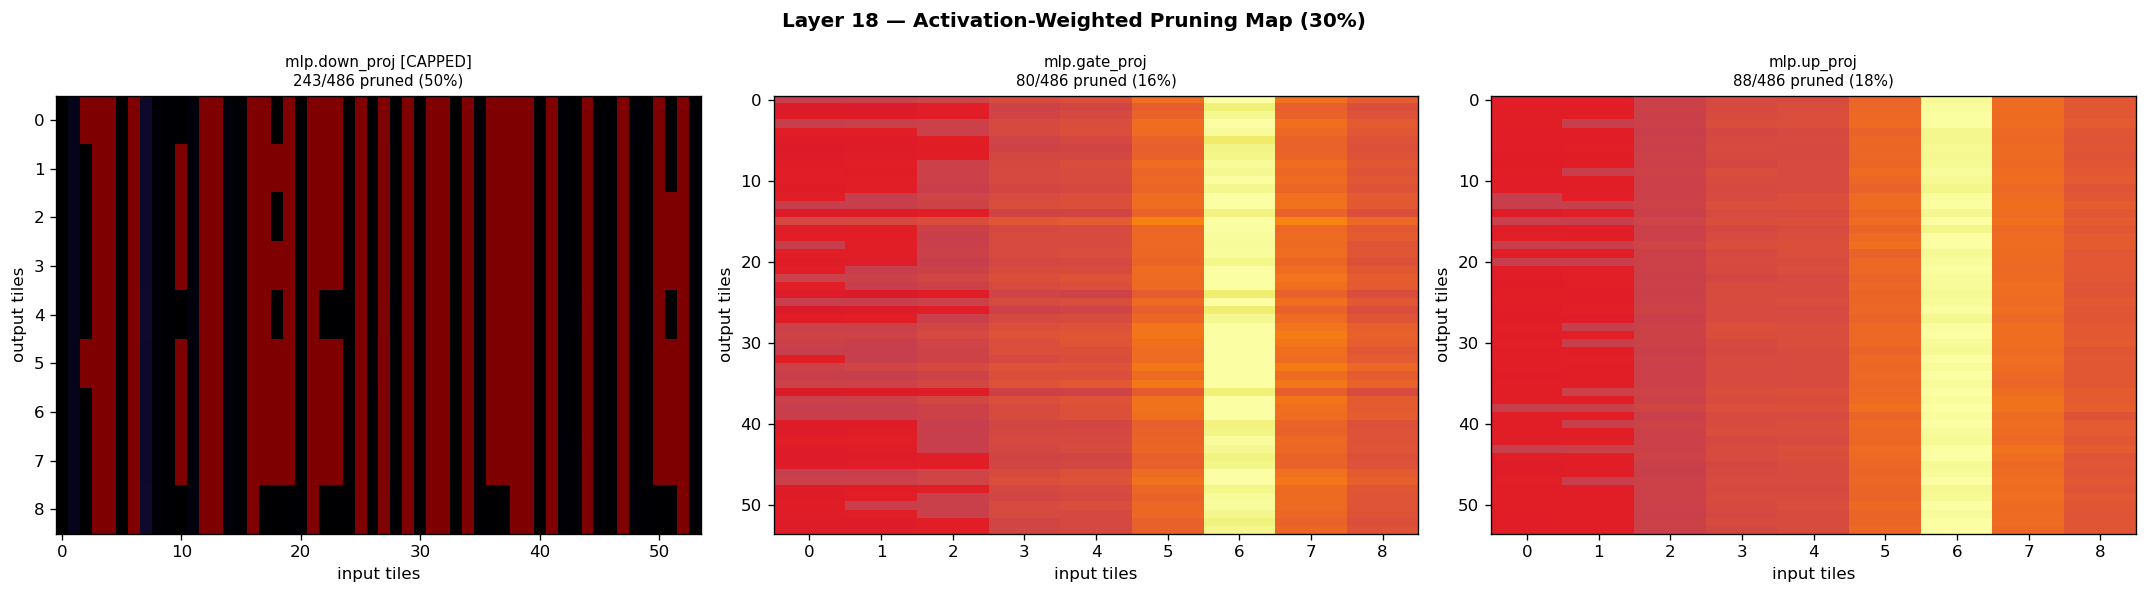

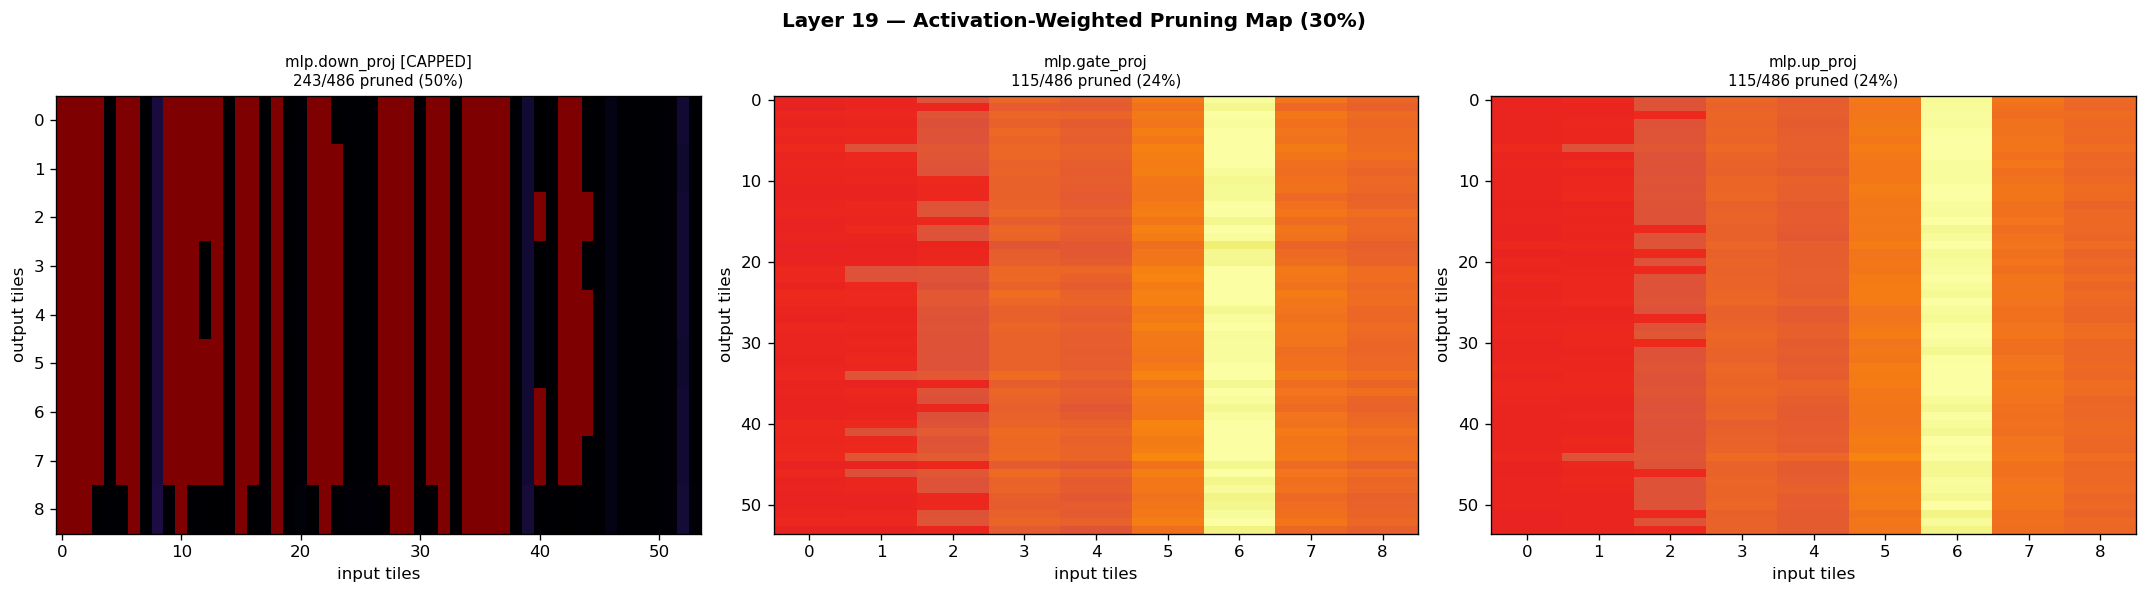

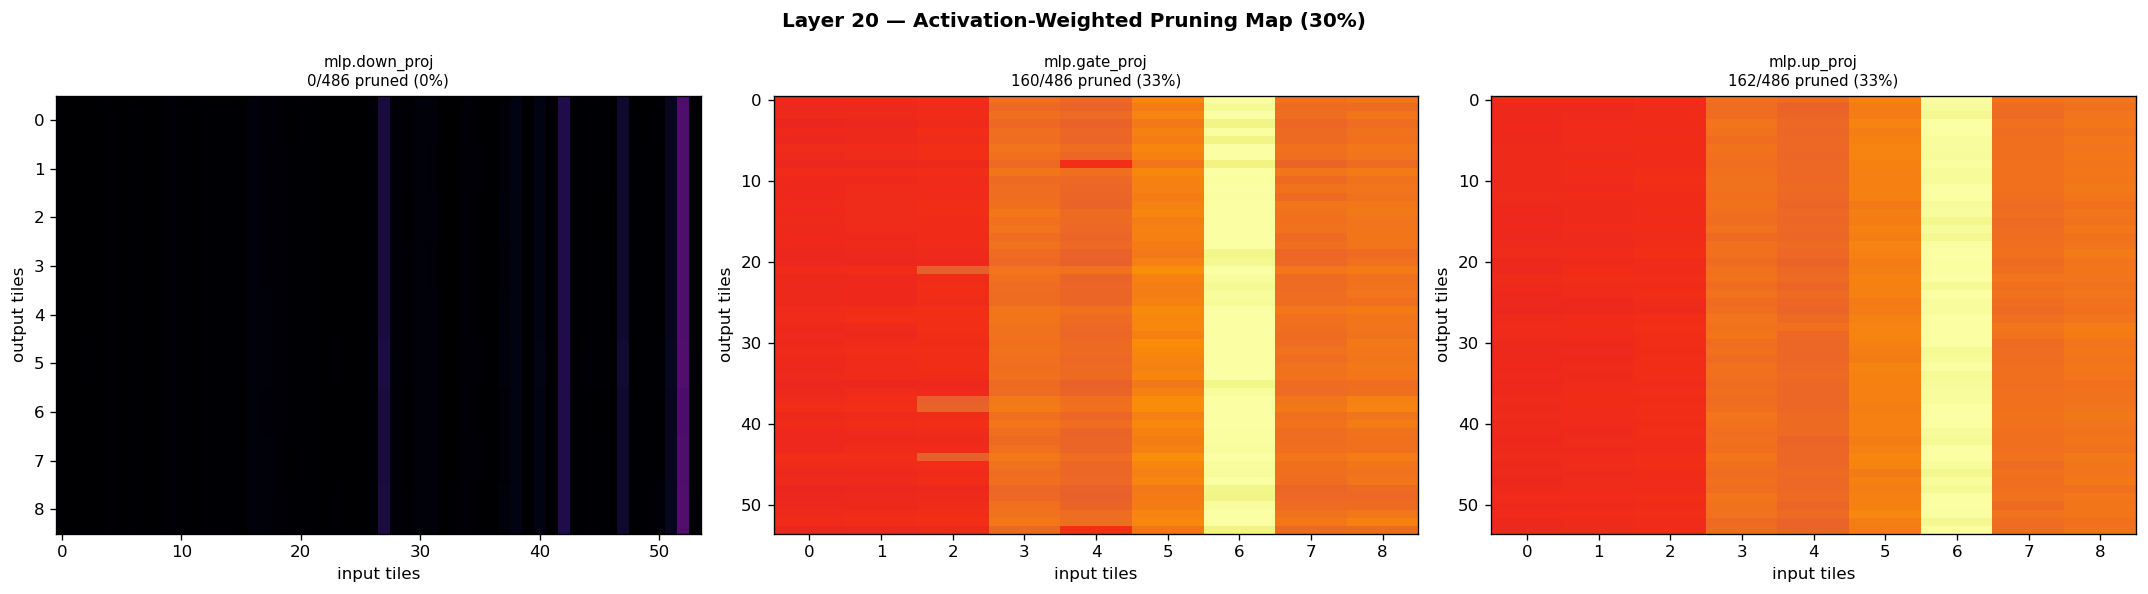

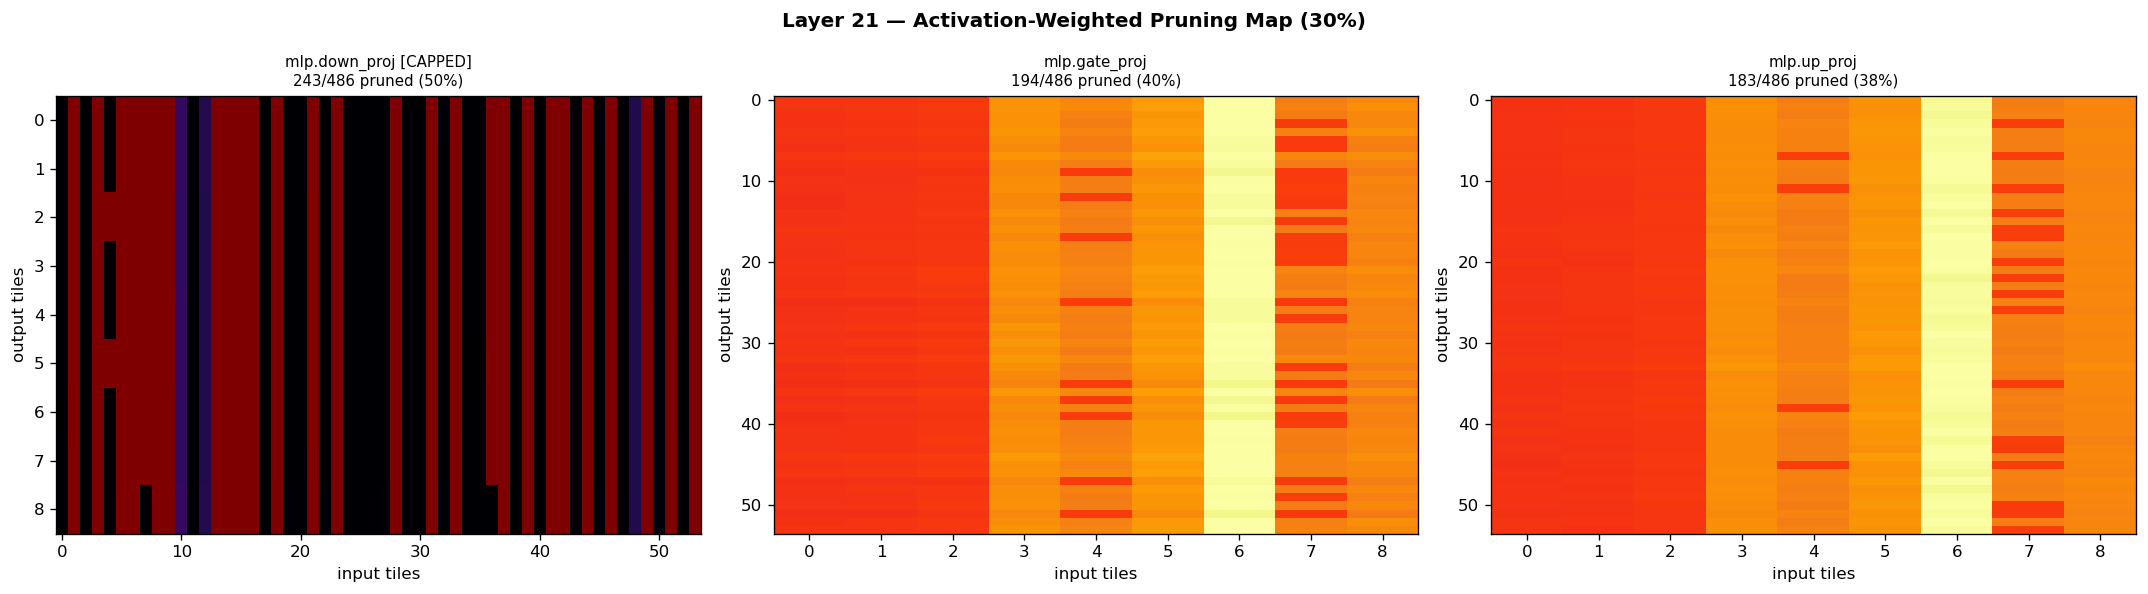

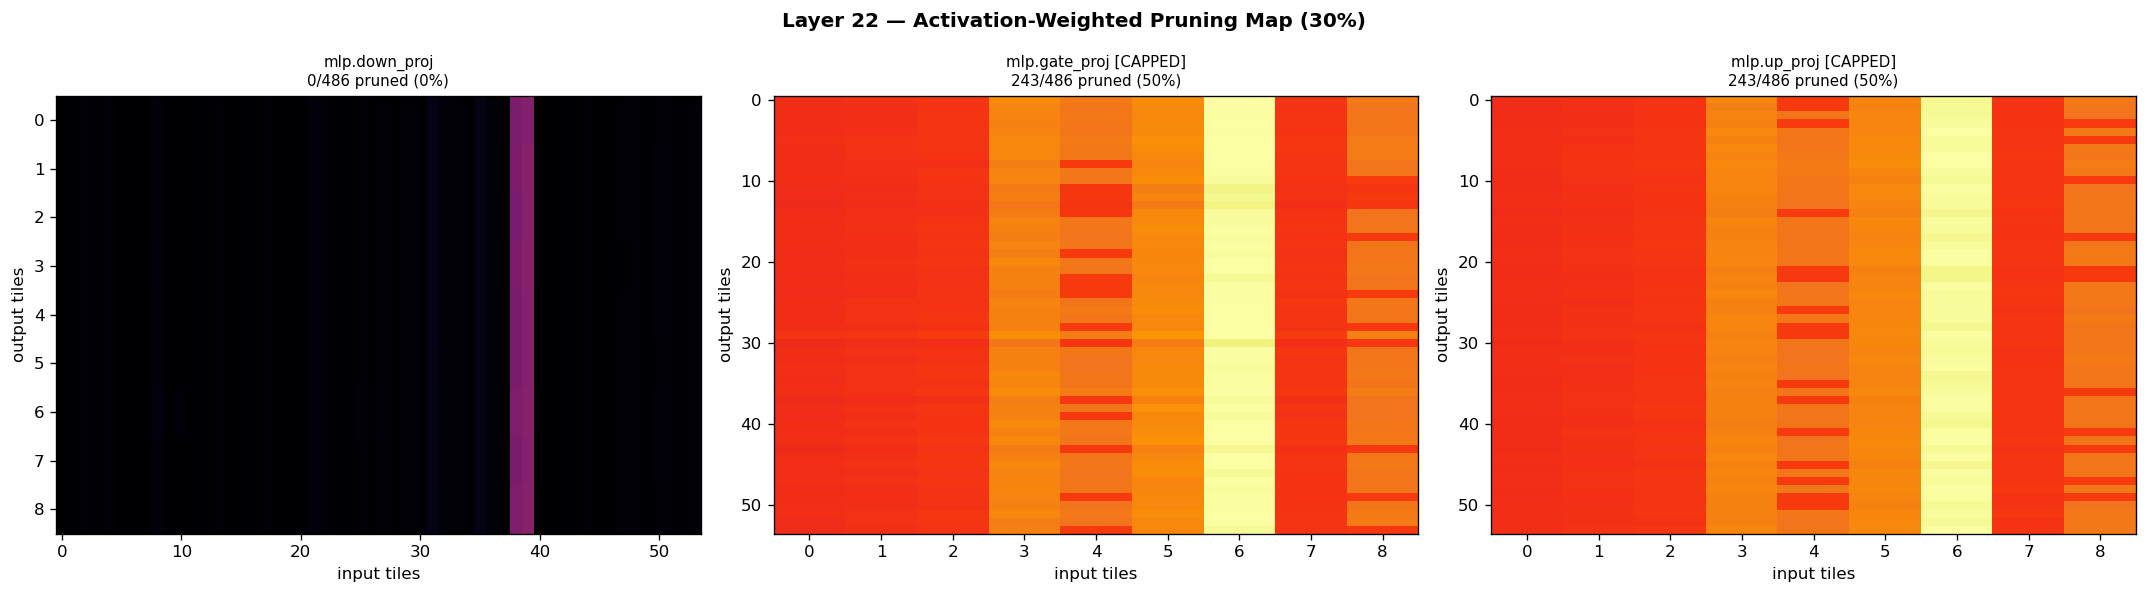

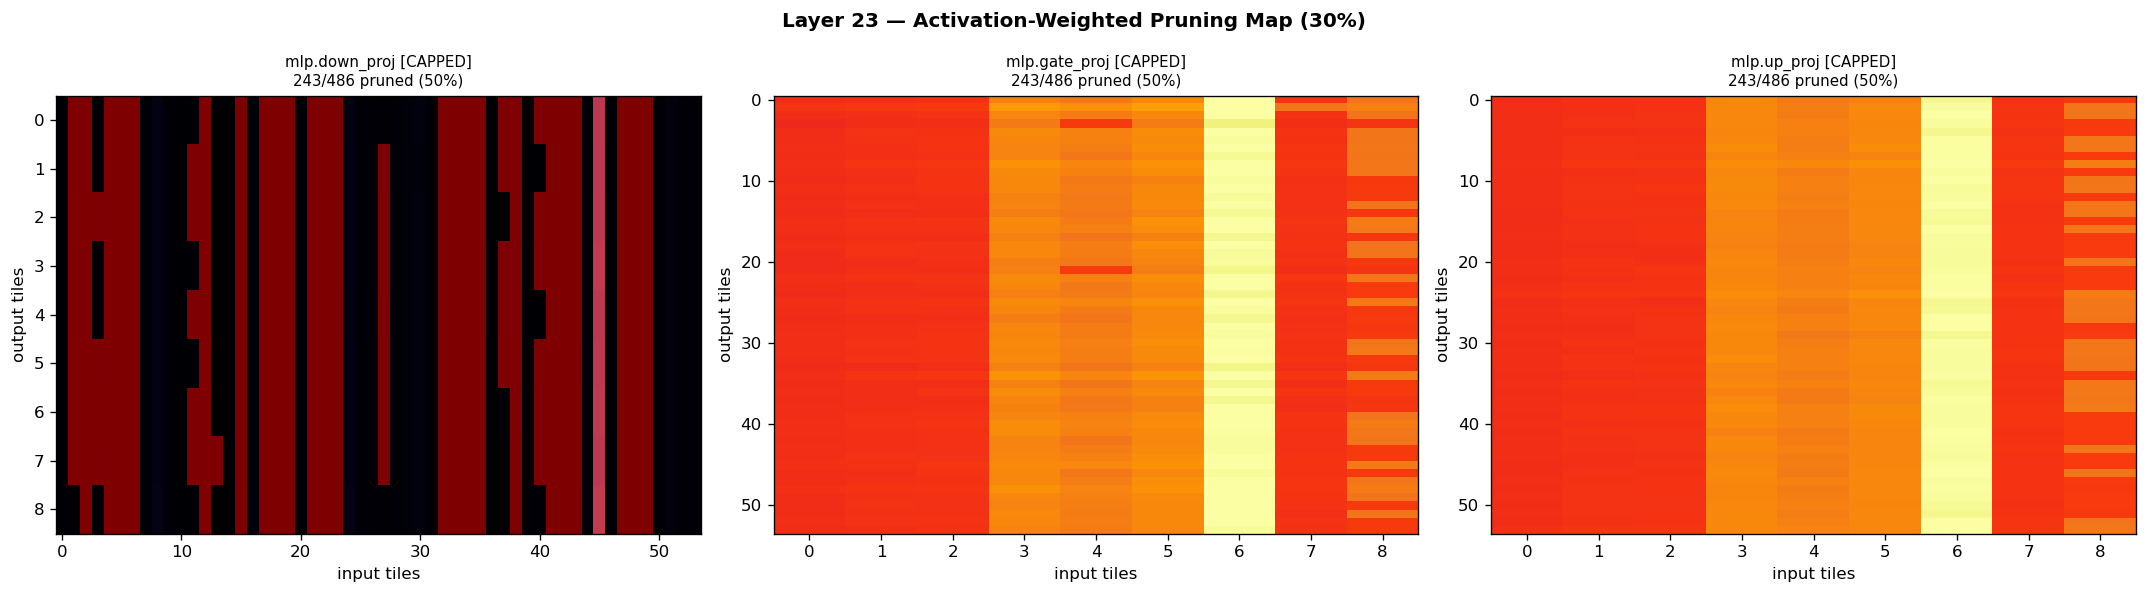

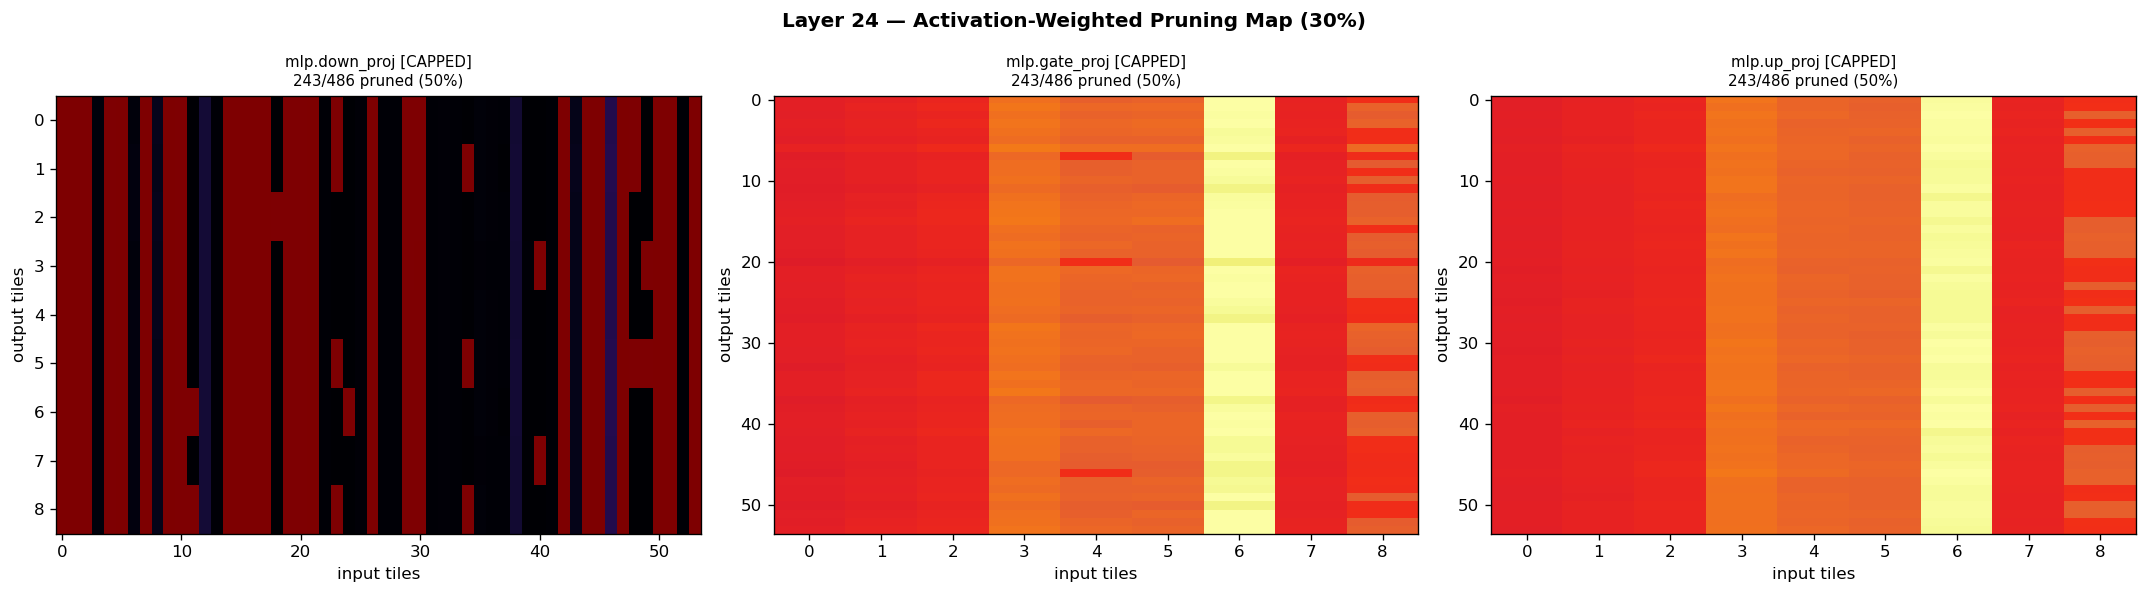

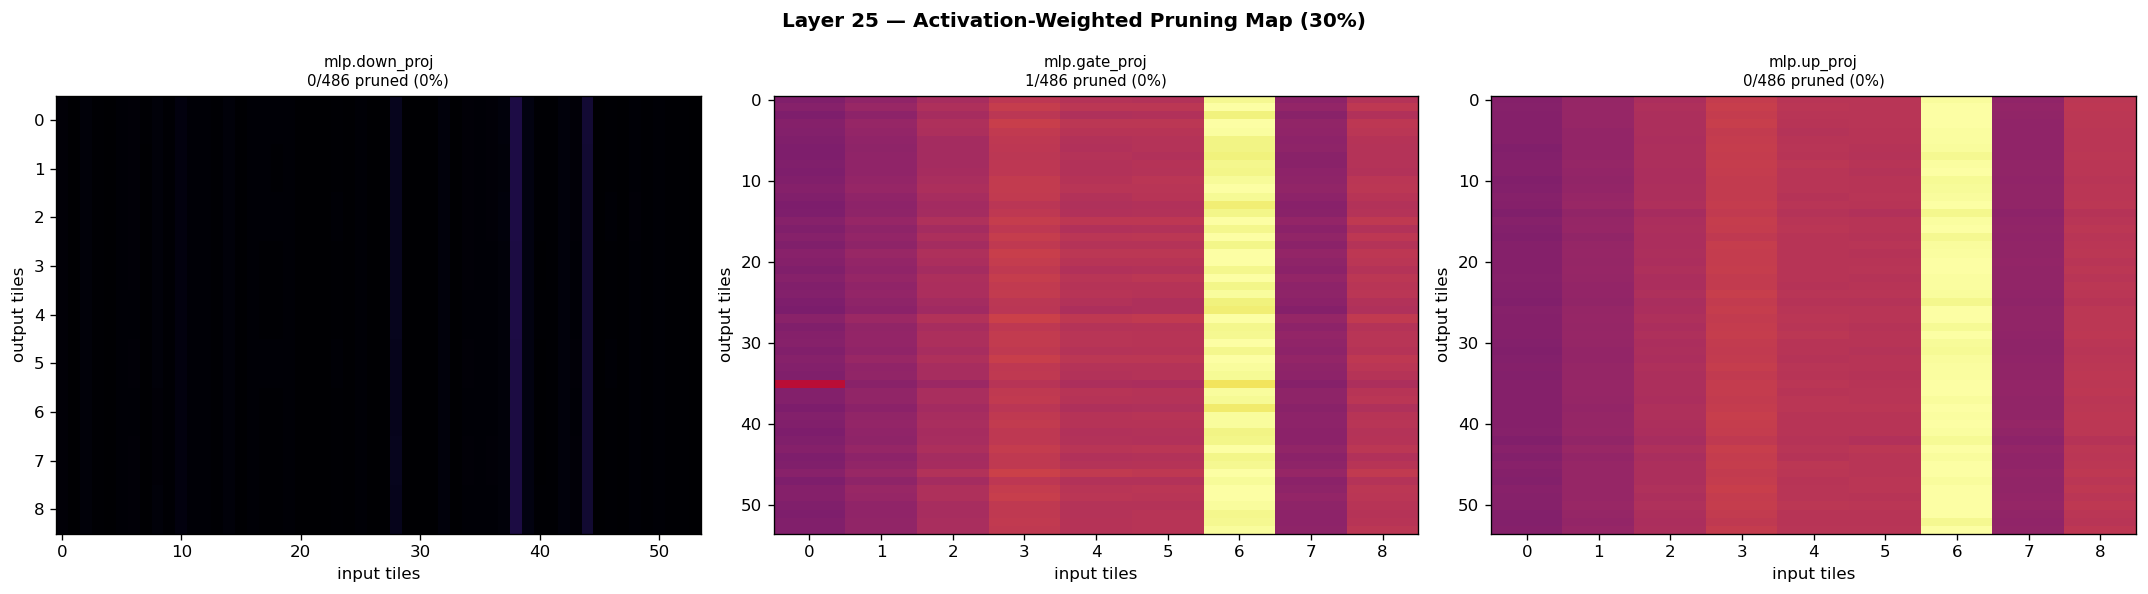

In [13]:
def get_mlp_components(layer_idx: int) -> dict:
    """Return only MLP components for a layer (raw scores)."""
    return {k: v for k, v in layer_components.get(layer_idx, {}).items()
            if any(p in k for p in config.PRUNE_TARGETS_PATTERNS)}

def get_mlp_actw(layer_idx: int) -> dict:
    """Return MLP components with activation-weighted raw scores."""
    return layer_components_actw.get(layer_idx, {})

def get_mlp_actw_norm(layer_idx: int) -> dict:
    """Return MLP components with activation-weighted normalized scores."""
    return layer_components_actw_norm.get(layer_idx, {})

def get_capped_mask_viz(norm_map: np.ndarray, threshold: float,
                        max_prune: float = config.MAX_PRUNE_PER_MATRIX) -> np.ndarray:
    global_mask = norm_map < threshold
    if global_mask.mean() <= max_prune:
        return global_mask
    local_threshold = float(np.percentile(norm_map.ravel(), max_prune * 100))
    return norm_map < local_threshold

def plot_pruning_map(layer_idx: int, raw_components: dict, norm_components: dict, threshold: float):
    """Show which tiles would be pruned. Heatmap uses activation-weighted raw, mask uses normalized."""
    n = len(raw_components)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    
    all_vals = np.concatenate([m.ravel() for m in raw_components.values()])
    vmin, vmax = np.percentile(all_vals, [2, 98])
    
    for ax, (comp_name, raw_map) in zip(axes, sorted(raw_components.items())):
        ax.imshow(raw_map, aspect="auto", cmap="inferno", vmin=vmin, vmax=vmax, interpolation="nearest")
        
        norm_map = norm_components.get(comp_name)
        if norm_map is not None:
            prune_mask = get_capped_mask_viz(norm_map, threshold)
        else:
            prune_mask = np.zeros_like(raw_map, dtype=bool)
        
        overlay = np.zeros((*raw_map.shape, 4))
        overlay[prune_mask] = [1, 0, 0, 0.5]
        ax.imshow(overlay, aspect="auto", interpolation="nearest")
        
        n_pruned = prune_mask.sum()
        n_total = prune_mask.size
        was_capped = (norm_map < threshold).mean() > config.MAX_PRUNE_PER_MATRIX if norm_map is not None else False
        cap_label = " [CAPPED]" if was_capped else ""
        ax.set_title(f"{comp_name}{cap_label}\n{n_pruned}/{n_total} pruned ({n_pruned/n_total*100:.0f}%)", fontsize=9)
        ax.set_xlabel("input tiles")
        ax.set_ylabel("output tiles")
    
    fig.suptitle(f"Layer {layer_idx} — Activation-Weighted Pruning Map ({PRUNE_RATIO*100:.0f}%)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

for li in range(n_layers):
    raw = get_mlp_actw(li)
    norm = get_mlp_actw_norm(li)
    if raw:
        plot_pruning_map(li, raw, norm, threshold)

## 7. Per-layer MLP pruning density

How much does each layer's MLP get pruned under the global threshold? Layers that lose more MLP tiles are the "expendable" ones. Layers that keep most tiles are the critical reasoning circuits — candidates for duplication.

In [ ]:
# Per-layer MLP pruning stats (using activation-weighted normalized scores)
# Uses get_capped_mask_viz per matrix to show the ACTUAL pruning density
# after the per-matrix cap is applied (not the uncapped global threshold).
layer_prune_ratios = []
layer_mean_importance = []

for li in range(n_layers):
    norm_comps = get_mlp_actw_norm(li)
    raw_comps = get_mlp_actw(li)
    if not norm_comps:
        layer_prune_ratios.append(0.0)
        layer_mean_importance.append(0.0)
        continue
    
    # Apply capped mask per matrix, then aggregate
    pruned_total = 0
    tiles_total = 0
    for comp_name, norm_map in norm_comps.items():
        capped_mask = get_capped_mask_viz(norm_map, threshold)
        pruned_total += capped_mask.sum()
        tiles_total += capped_mask.size
    
    layer_prune_ratios.append(pruned_total / tiles_total if tiles_total > 0 else 0.0)
    raw_tiles = np.concatenate([m.ravel() for m in raw_comps.values()])
    layer_mean_importance.append(raw_tiles.mean())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

colors = plt.cm.RdYlGn_r(np.array(layer_prune_ratios))
ax1.bar(range(n_layers), [r * 100 for r in layer_prune_ratios], color=colors, edgecolor="black", linewidth=0.3)
ax1.axhline(PRUNE_RATIO * 100, color="red", linestyle="--", alpha=0.5, label=f"Target ({PRUNE_RATIO*100:.0f}%)")
ax1.axhline(config.MAX_PRUNE_PER_MATRIX * 100, color="orange", linestyle=":", alpha=0.5, label=f"Per-matrix cap ({config.MAX_PRUNE_PER_MATRIX*100:.0f}%)")
ax1.set_ylabel("MLP tiles pruned (%)")
ax1.set_title("Per-Layer MLP Pruning Density (activation-weighted, capped)", fontweight="bold")
ax1.legend()

max_imp = max(layer_mean_importance) if max(layer_mean_importance) > 0 else 1
colors2 = plt.cm.inferno(np.array(layer_mean_importance) / max_imp)
ax2.bar(range(n_layers), layer_mean_importance, color=colors2, edgecolor="black", linewidth=0.3)
ax2.set_xlabel("Layer index")
ax2.set_ylabel("Mean activation-weighted importance")
ax2.set_title("Per-Layer Mean Importance (activation-weighted)", fontweight="bold")

plt.tight_layout()
plt.show()

most_pruned = np.argmax(layer_prune_ratios)
least_pruned = np.argmin(layer_prune_ratios)
print(f"Most pruned layer:  {most_pruned} ({layer_prune_ratios[most_pruned]*100:.1f}% MLP tiles removed)")
print(f"Least pruned layer: {least_pruned} ({layer_prune_ratios[least_pruned]*100:.1f}% MLP tiles removed)")
print(f"\nDuplication candidates (least pruned = most important):"
      f" layers {sorted(np.argsort(layer_prune_ratios)[:5])}")

## 8. MLP importance distribution — where do the tiles fall?

Histogram of MLP tile importance scores (the pruning pool). The vertical line shows the pruning threshold. A bimodal split = genuinely dead regions exist.

In [ ]:
all_mlp_actw_norm_scores = np.concatenate([m.ravel() for m in importance_maps_actw_norm.values()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(all_mlp_actw_norm_scores, bins=100, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
ax1.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Prune threshold ({PRUNE_RATIO*100:.0f}%)")
ax1.set_xlabel("Normalized tile importance (z-score)")
ax1.set_ylabel("Count")
ax1.set_title("MLP Tile Importance Distribution (activation-weighted, normalized)")
ax1.legend()

ax2.hist(all_mlp_actw_norm_scores, bins=100, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
ax2.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Prune threshold ({PRUNE_RATIO*100:.0f}%)")
ax2.set_yscale("log")
ax2.set_xlabel("Normalized tile importance (z-score)")
ax2.set_ylabel("Count (log)")
ax2.set_title("MLP Distribution — activation-weighted (log scale)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"MLP tiles (activation-weighted): {len(all_mlp_actw_norm_scores)}")
print(f"Min: {all_mlp_actw_norm_scores.min():.4f}, Max: {all_mlp_actw_norm_scores.max():.4f}")
print(f"Mean: {all_mlp_actw_norm_scores.mean():.4f}, Std: {all_mlp_actw_norm_scores.std():.4f}")
print(f"Median: {np.median(all_mlp_actw_norm_scores):.4f}")

## 9. Attention vs MLP comparison (visualization only)

How do importance distributions compare? Attention is shown for context but is **not** in the pruning pool.

> **Future experiment:** Try tile-pruning attention projections and measure impact on head coherence.

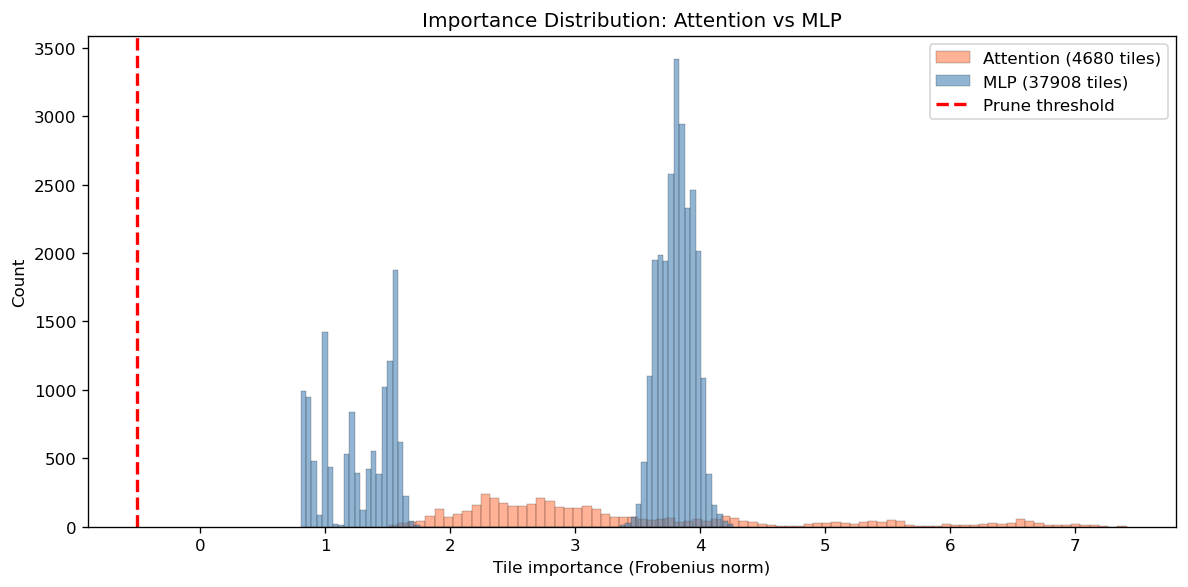

Attention — mean: 3.3170, would-be-pruned: 0.0%
MLP      — mean: 2.9655, pruned:          0.0%

Note: Attention tiles are NOT pruned — shown for comparison only.


In [16]:
# Group scores by component type
attn_keywords = ["q_proj", "k_proj", "v_proj", "o_proj", "qkv_proj", "self_attn"]
mlp_keywords = ["gate_proj", "up_proj", "down_proj", "mlp"]

attn_scores = []
mlp_scores = []

for name, imp_map in importance_maps_all.items():
    name_lower = name.lower()
    if any(k in name_lower for k in attn_keywords):
        attn_scores.extend(imp_map.ravel().tolist())
    elif any(k in name_lower for k in mlp_keywords):
        mlp_scores.extend(imp_map.ravel().tolist())

fig, ax = plt.subplots(figsize=(10, 5))
if attn_scores:
    ax.hist(attn_scores, bins=80, alpha=0.6, label=f"Attention ({len(attn_scores)} tiles)", color="coral", edgecolor="black", linewidth=0.2)
if mlp_scores:
    ax.hist(mlp_scores, bins=80, alpha=0.6, label=f"MLP ({len(mlp_scores)} tiles)", color="steelblue", edgecolor="black", linewidth=0.2)
ax.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Prune threshold")
ax.set_xlabel("Tile importance (Frobenius norm)")
ax.set_ylabel("Count")
ax.set_title("Importance Distribution: Attention vs MLP")
ax.legend()
plt.tight_layout()
plt.show()

if attn_scores and mlp_scores:
    attn_arr = np.array(attn_scores)
    mlp_arr = np.array(mlp_scores)
    print(f"Attention — mean: {attn_arr.mean():.4f}, would-be-pruned: {(attn_arr < threshold).mean()*100:.1f}%")
    print(f"MLP      — mean: {mlp_arr.mean():.4f}, pruned:          {(mlp_arr < threshold).mean()*100:.1f}%")
    print(f"\nNote: Attention tiles are NOT pruned — shown for comparison only.")

## 10. Zoomed spatial view — single weight matrix deep dive

Pick any layer/component and see the full tile grid at high resolution. Useful for spotting spatial patterns — do dead tiles cluster in rows (output neurons), columns (input features), or patches?

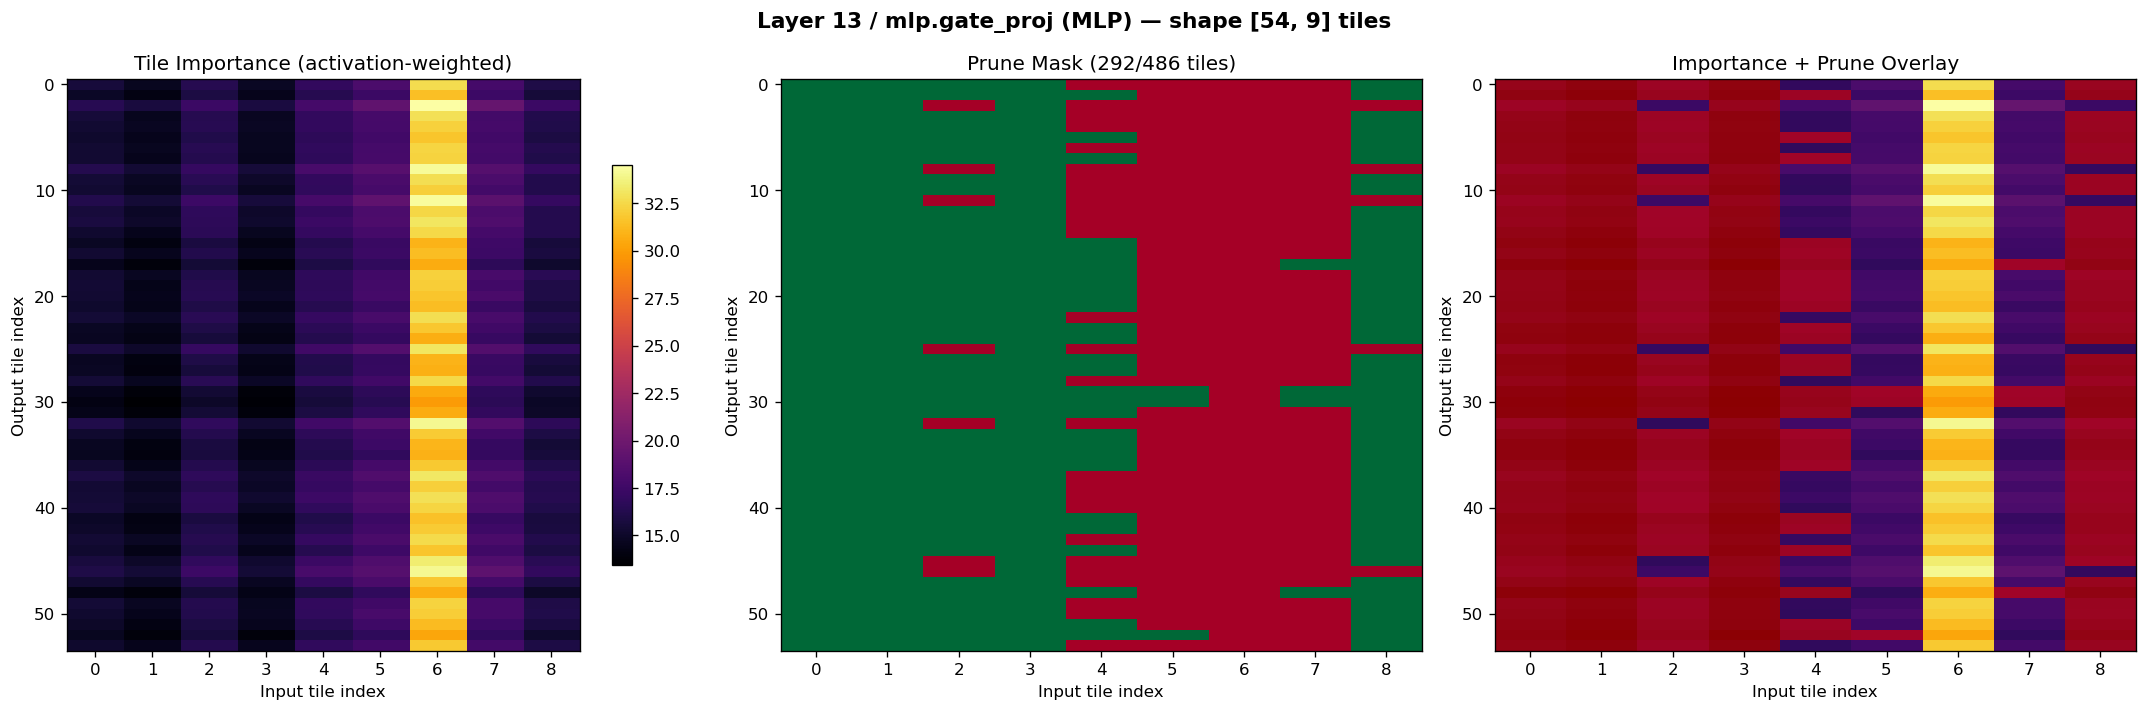

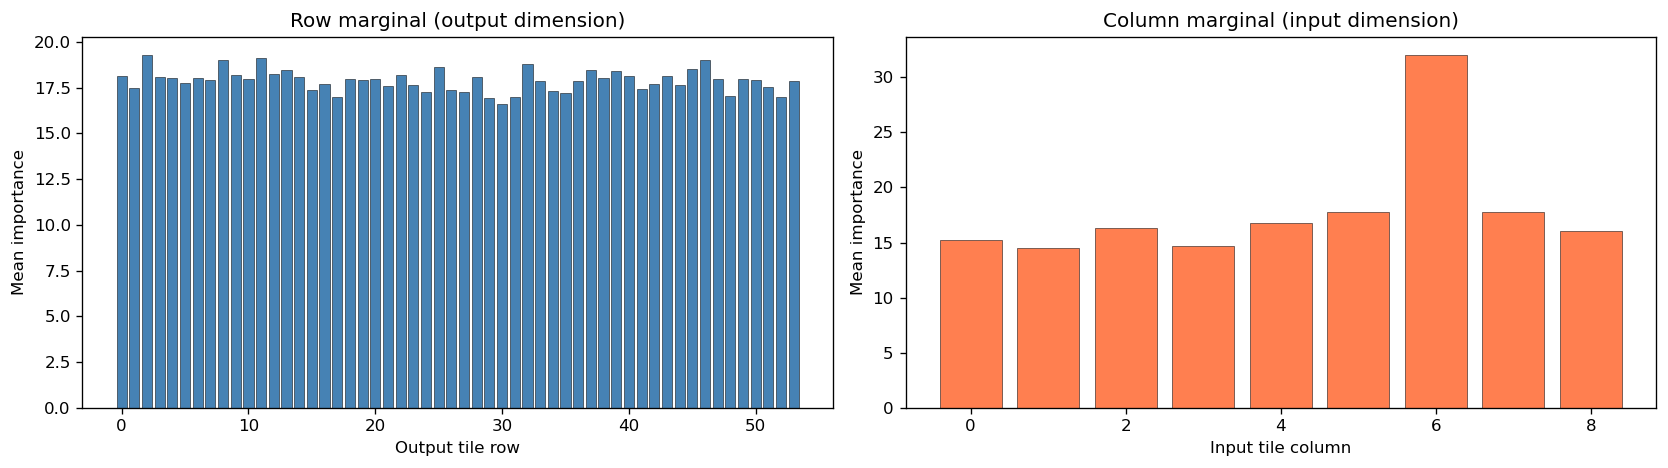

In [17]:
# ---- CONFIGURE: pick a layer and MLP component to zoom into ----
ZOOM_LAYER = n_layers // 2
mlp_comps = get_mlp_actw(ZOOM_LAYER)
mlp_comps_n = get_mlp_actw_norm(ZOOM_LAYER)
ZOOM_COMP = list(mlp_comps.keys())[0]
# ----------------------------------------------------------------

imp_map = mlp_comps[ZOOM_COMP]
norm_map = mlp_comps_n[ZOOM_COMP]
prune_mask = norm_map < threshold

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im = axes[0].imshow(imp_map, aspect="auto", cmap="inferno", interpolation="nearest")
axes[0].set_title("Tile Importance (activation-weighted)")
fig.colorbar(im, ax=axes[0], shrink=0.7)

axes[1].imshow(prune_mask.astype(float), aspect="auto", cmap="RdYlGn", interpolation="nearest", vmin=0, vmax=1)
axes[1].set_title(f"Prune Mask ({prune_mask.sum()}/{prune_mask.size} tiles)")

axes[2].imshow(imp_map, aspect="auto", cmap="inferno", interpolation="nearest")
overlay = np.zeros((*imp_map.shape, 4))
overlay[prune_mask] = [1, 0, 0, 0.55]
axes[2].imshow(overlay, aspect="auto", interpolation="nearest")
axes[2].set_title("Importance + Prune Overlay")

for ax in axes:
    ax.set_xlabel("Input tile index")
    ax.set_ylabel("Output tile index")

fig.suptitle(f"Layer {ZOOM_LAYER} / {ZOOM_COMP} (MLP) — shape {list(imp_map.shape)} tiles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Row/column marginals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

row_importance = imp_map.mean(axis=1)
col_importance = imp_map.mean(axis=0)

ax1.bar(range(len(row_importance)), row_importance, color="steelblue", edgecolor="black", linewidth=0.3)
ax1.set_xlabel("Output tile row")
ax1.set_ylabel("Mean importance")
ax1.set_title("Row marginal (output dimension)")

ax2.bar(range(len(col_importance)), col_importance, color="coral", edgecolor="black", linewidth=0.3)
ax2.set_xlabel("Input tile column")
ax2.set_ylabel("Mean importance")
ax2.set_title("Column marginal (input dimension)")

plt.tight_layout()
plt.show()

## 11. Multi-threshold comparison

How does the pruning map change as we increase the pruning target? Shows the same layer at 10%, 20%, 30%, 50% pruning side by side.

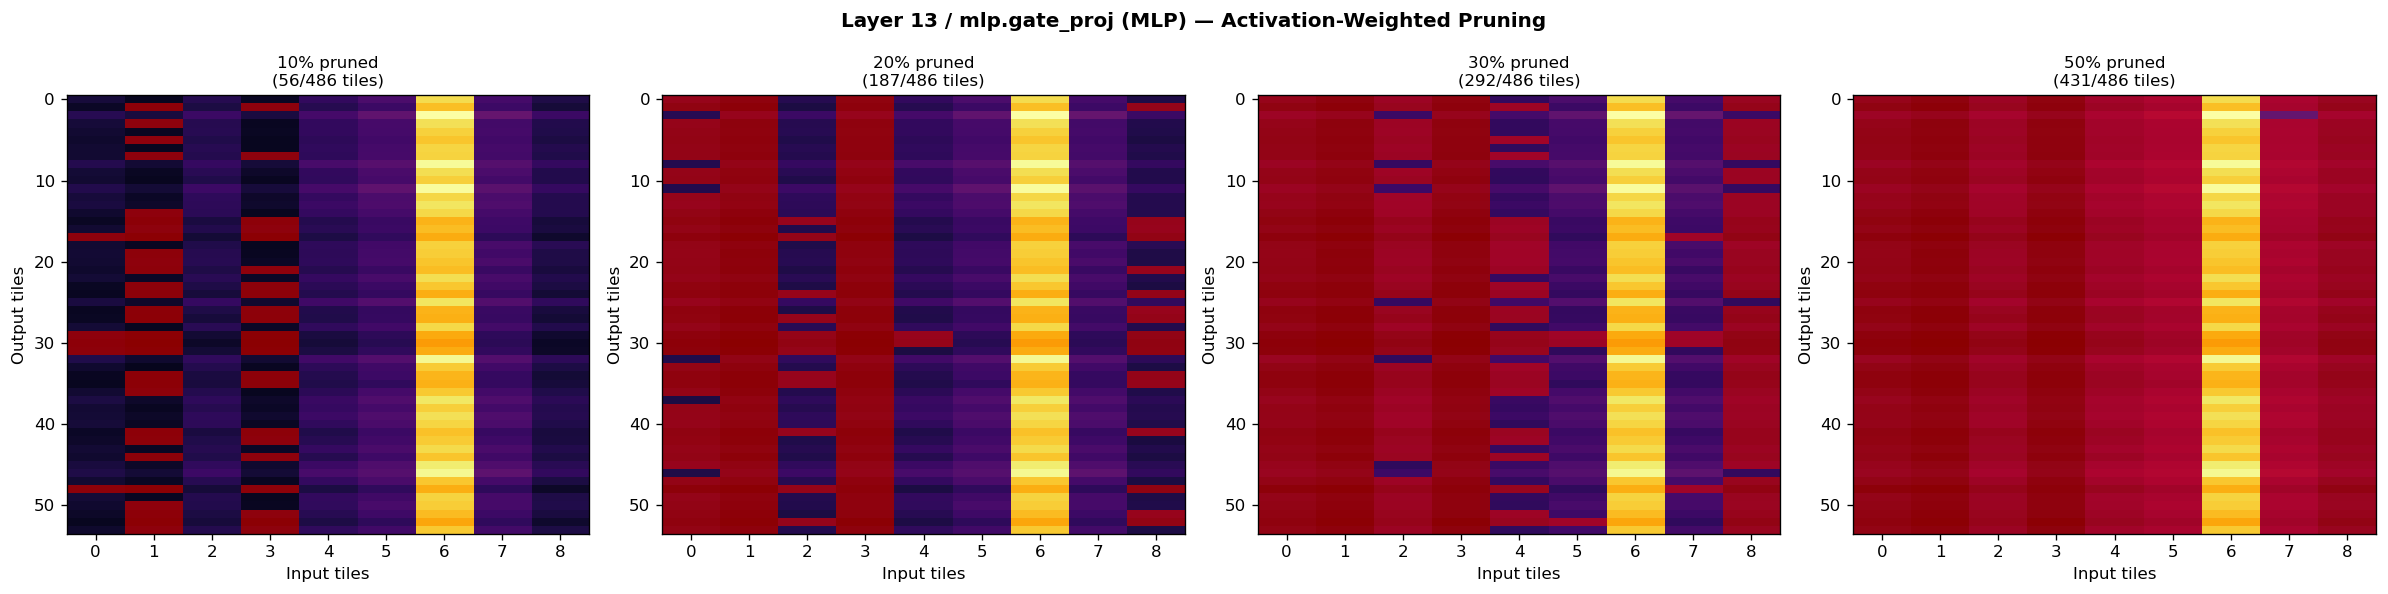

In [18]:
COMPARE_LAYER = n_layers // 2
mlp_comps = get_mlp_actw(COMPARE_LAYER)
mlp_comps_n = get_mlp_actw_norm(COMPARE_LAYER)
COMPARE_COMP = max(mlp_comps.keys(), key=lambda c: mlp_comps[c].size)

raw_map = mlp_comps[COMPARE_COMP]
norm_map = mlp_comps_n[COMPARE_COMP]
ratios = [0.10, 0.20, 0.30, 0.50]

fig, axes = plt.subplots(1, len(ratios), figsize=(5 * len(ratios), 5))

for ax, ratio in zip(axes, ratios):
    thresh = compute_global_threshold(importance_maps_actw_norm, ratio)
    mask = norm_map < thresh
    
    ax.imshow(raw_map, aspect="auto", cmap="inferno", interpolation="nearest")
    overlay = np.zeros((*raw_map.shape, 4))
    overlay[mask] = [1, 0, 0, 0.55]
    ax.imshow(overlay, aspect="auto", interpolation="nearest")
    
    ax.set_title(f"{ratio*100:.0f}% pruned\n({mask.sum()}/{mask.size} tiles)", fontsize=10)
    ax.set_xlabel("Input tiles")
    ax.set_ylabel("Output tiles")

fig.suptitle(f"Layer {COMPARE_LAYER} / {COMPARE_COMP} (MLP) — Activation-Weighted Pruning",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 12. Sparsified Model Evaluation — Frobenius vs Activation-Weighted vs Gradient (Taylor)

Run all three scoring methods through the same pruning + MMLU eval pipeline and compare.

In [19]:
from eval_mmlu import evaluate, print_results, save_results
import re

def get_layer_idx(param_name: str) -> int | None:
    """Extract layer index from a parameter name like 'model.layers.5.mlp.gate_proj.weight'."""
    m = re.search(r'\.layers\.(\d+)\.', param_name)
    return int(m.group(1)) if m else None

def get_capped_mask(norm_map: np.ndarray, threshold: float,
                    max_prune: float = config.MAX_PRUNE_PER_MATRIX) -> np.ndarray:
    """
    Compute pruning mask with a per-matrix safety cap.
    If the global threshold would prune more than max_prune fraction of this
    matrix's tiles, use a local threshold that caps at max_prune instead.
    """
    global_mask = norm_map < threshold
    if global_mask.mean() <= max_prune:
        return global_mask
    local_threshold = float(np.percentile(norm_map.ravel(), max_prune * 100))
    return norm_map < local_threshold

def apply_tile_pruning(model, importance_maps_norm: dict, threshold: float,
                       tile_r: int = TILE_R, tile_c: int = TILE_C):
    """
    Zero out tiles below the normalized threshold in the model's MLP weights,
    with a per-matrix cap and layer skip list.
    Modifies the model in-place.
    """
    total_pruned = 0
    total_tiles = 0
    capped_count = 0
    skipped_layers = set()
    
    for name, param in model.named_parameters():
        if name not in importance_maps_norm:
            continue
        
        # Skip protected layers
        layer_idx = get_layer_idx(name)
        if layer_idx is not None and layer_idx in config.PRUNE_SKIP_LAYERS:
            skipped_layers.add(layer_idx)
            continue
        
        norm_map = importance_maps_norm[name]
        uncapped_ratio = (norm_map < threshold).mean()
        mask = get_capped_mask(norm_map, threshold)
        
        if uncapped_ratio > config.MAX_PRUNE_PER_MATRIX:
            capped_count += 1
        
        total_pruned += mask.sum()
        total_tiles += mask.size
        
        if not mask.any():
            continue
        
        with torch.no_grad():
            W = param.data
            n_rows, n_cols = norm_map.shape
            for ri in range(n_rows):
                for ci in range(n_cols):
                    if mask[ri, ci]:
                        r_start = ri * tile_r
                        r_end = r_start + tile_r
                        c_start = ci * tile_c
                        c_end = c_start + tile_c
                        W[r_start:r_end, c_start:c_end] = 0.0
    
    if skipped_layers:
        print(f"  Protected layers (skipped): {sorted(skipped_layers)}")
    if capped_count > 0:
        print(f"  Cap applied to {capped_count} matrices (max {config.MAX_PRUNE_PER_MATRIX*100:.0f}% per matrix)")
    
    return total_pruned, total_tiles

def restore_model(model):
    """Reload original weights."""
    orig = AutoModelForCausalLM.from_pretrained(
        config.MODEL_NAME,
        torch_dtype=getattr(torch, config.TORCH_DTYPE),
        device_map=config.DEVICE,
    )
    with torch.no_grad():
        for (name, param), (_, orig_param) in zip(
            model.named_parameters(), orig.named_parameters()
        ):
            param.copy_(orig_param)
    del orig
    torch.cuda.empty_cache()

print(f"Pruning functions ready.")
print(f"  Per-matrix cap: {config.MAX_PRUNE_PER_MATRIX*100:.0f}%")
print(f"  Protected layers: {config.PRUNE_SKIP_LAYERS}")

Pruning functions ready.
  Per-matrix cap: 50%
  Protected layers: []


In [20]:
import json, time
from pathlib import Path

EVAL_RATIOS = [0.10, 0.20, 0.30, 0.50]

baseline_path = Path(config.RESULTS_DIR) / "mmlu_baseline.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline_results = json.load(f)
    baseline_acc = baseline_results["overall"]["accuracy"]
    print(f"Baseline loaded: {baseline_acc*100:.1f}%")
else:
    print("WARNING: No baseline results found.")
    baseline_acc = None

# --- Benchmark all three methods ---
methods = {
    "frobenius": importance_maps_mlp_norm,
    "actw": importance_maps_actw_norm,
    "gradient": importance_maps_grad_norm,
}

all_results = {}  # (method, ratio) -> results

for method_name, norm_maps in methods.items():
    print(f"\n{'#'*60}")
    print(f"  METHOD: {method_name.upper()}")
    print(f"{'#'*60}")
    
    for ratio in EVAL_RATIOS:
        print(f"\n{'='*60}")
        print(f"  {method_name} — {ratio*100:.0f}% pruning")
        print(f"{'='*60}")
        
        restore_model(model)
        
        thresh = compute_global_threshold(norm_maps, ratio)
        pruned, total = apply_tile_pruning(model, norm_maps, thresh)
        print(f"Pruned {pruned}/{total} MLP tiles ({pruned/total*100:.1f}%)")
        
        t0 = time.time()
        tag = f"{method_name}_{int(ratio*100)}pct"
        results = evaluate(model, tokenizer, tag=tag)
        elapsed = time.time() - t0
        
        results["meta"] = {
            "method": method_name,
            "prune_ratio": ratio,
            "tiles_pruned": int(pruned),
            "tiles_total": int(total),
            "eval_time_s": round(elapsed, 1),
        }
        
        print_results(results)
        save_results(results)
        all_results[(method_name, ratio)] = results

print("\nAll evaluations complete.")

Baseline loaded: 30.8%

############################################################
  METHOD: FROBENIUS
############################################################

  frobenius — 10% pruning
  Cap applied to 5 matrices (max 50% per matrix)
Pruned 3112/37908 MLP tiles (8.2%)


[frobenius_10pct] MMLU subjects: 100%|███████████████████████████████| 10/10 [01:03<00:00,  6.35s/it]



  MMLU Results — frobenius_10pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  anatomy                        ███░░░░░░░░░░░░░░░░░  17.0% (23/135)
  college_chemistry              ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  25.0% (25/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  22.8% (26/114)
  global_facts                   ███░░░░░░░░░░░░░░░░░  18.0% (18/100)
  machine_learning               █████░░░░░░░░░░░░░░░  29.5% (33/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  23.7% (212/895)
  professional_medicine          ███░░░░░░░░░░░░░░░░░  19.1% (52/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  28.0% (28/100)
────────────────────────────────────────────────────────────
  OVERALL                                       22.7% (461/2028)

Results saved to results/mmlu_frobenius_10pct.json

  frobenius — 20% pruning
  Cap applied to 17 matrices (max 50% per matrix)
Pruned 509

[frobenius_20pct] MMLU subjects: 100%|███████████████████████████████| 10/10 [01:04<00:00,  6.42s/it]



  MMLU Results — frobenius_20pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  anatomy                        ████░░░░░░░░░░░░░░░░  20.7% (28/135)
  college_chemistry              ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  college_computer_science       ████░░░░░░░░░░░░░░░░  24.0% (24/100)
  econometrics                   █████░░░░░░░░░░░░░░░  25.4% (29/114)
  global_facts                   ████░░░░░░░░░░░░░░░░  24.0% (24/100)
  machine_learning               █████░░░░░░░░░░░░░░░  29.5% (33/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  23.8% (213/895)
  professional_medicine          ███░░░░░░░░░░░░░░░░░  17.6% (48/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  28.0% (28/100)
────────────────────────────────────────────────────────────
  OVERALL                                       23.2% (471/2028)

Results saved to results/mmlu_frobenius_20pct.json

  frobenius — 30% pruning
  Cap applied to 23 matrices (max 50% per matrix)
Pruned 677

...


  MMLU Results — gradient_20pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  23.0% (23/100)
  anatomy                        ████████░░░░░░░░░░░░  44.4% (60/135)
  college_chemistry              █████░░░░░░░░░░░░░░░  28.0% (28/100)
  college_computer_science       ███████░░░░░░░░░░░░░  37.0% (37/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  22.8% (26/114)
  global_facts                   ██████░░░░░░░░░░░░░░  31.0% (31/100)
  machine_learning               ██████░░░░░░░░░░░░░░  32.1% (36/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  23.8% (213/895)
  professional_medicine          ████░░░░░░░░░░░░░░░░  23.5% (64/272)
  us_foreign_policy              ███████████░░░░░░░░░  56.0% (56/100)
────────────────────────────────────────────────────────────
  OVERALL                                       28.3% (574/2028)

Results saved to results/mmlu_gradient_20pct.json

  gradient — 30% pruning
  Cap applied to 23 matrices (max 50% per matrix)
Pruned 6537/3

[gradient_30pct] MMLU subjects: 100%|████████████████████████████████| 10/10 [01:03<00:00,  6.37s/it]



  MMLU Results — gradient_30pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  anatomy                        ██████░░░░░░░░░░░░░░  32.6% (44/135)
  college_chemistry              ████░░░░░░░░░░░░░░░░  23.0% (23/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  28.0% (28/100)
  econometrics                   ███░░░░░░░░░░░░░░░░░  18.4% (21/114)
  global_facts                   ██████░░░░░░░░░░░░░░  33.0% (33/100)
  machine_learning               ██████░░░░░░░░░░░░░░  32.1% (36/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  23.9% (214/895)
  professional_medicine          ████░░░░░░░░░░░░░░░░  21.3% (58/272)
  us_foreign_policy              ███████████░░░░░░░░░  56.0% (56/100)
────────────────────────────────────────────────────────────
  OVERALL                                       26.4% (535/2028)

Results saved to results/mmlu_gradient_30pct.json

  gradient — 50% pruning
  Cap applied to 39 matrices (max 50% per matrix)
Pruned 10204/

[gradient_50pct] MMLU subjects: 100%|████████████████████████████████| 10/10 [01:02<00:00,  6.30s/it]


  MMLU Results — gradient_50pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  23.0% (23/100)
  anatomy                        ████░░░░░░░░░░░░░░░░  23.7% (32/135)
  college_chemistry              ███░░░░░░░░░░░░░░░░░  17.0% (17/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  26.0% (26/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  21.1% (24/114)
  global_facts                   ███░░░░░░░░░░░░░░░░░  18.0% (18/100)
  machine_learning               █████░░░░░░░░░░░░░░░  29.5% (33/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  23.8% (213/895)
  professional_medicine          ███░░░░░░░░░░░░░░░░░  18.4% (50/272)
  us_foreign_policy              ████░░░░░░░░░░░░░░░░  20.0% (20/100)
────────────────────────────────────────────────────────────
  OVERALL                                       22.5% (456/2028)

Results saved to results/mmlu_gradient_50pct.json

All evaluations complete.


## 13. Results Comparison — Frobenius vs Activation-Weighted vs Gradient (Taylor)

Variant                 Frobenius    ActWeight     Gradient     Best
--------------------------------------------------------------------
Baseline                    30.8%        30.8%        30.8%
Pruned 10%                  22.7%        23.6%        27.3%    Grad
Pruned 20%                  23.2%        22.9%        28.3%    Grad
Pruned 30%                  24.5%        28.1%        26.4%    ActW
Pruned 50%                  26.3%        22.4%        22.5%    Frob


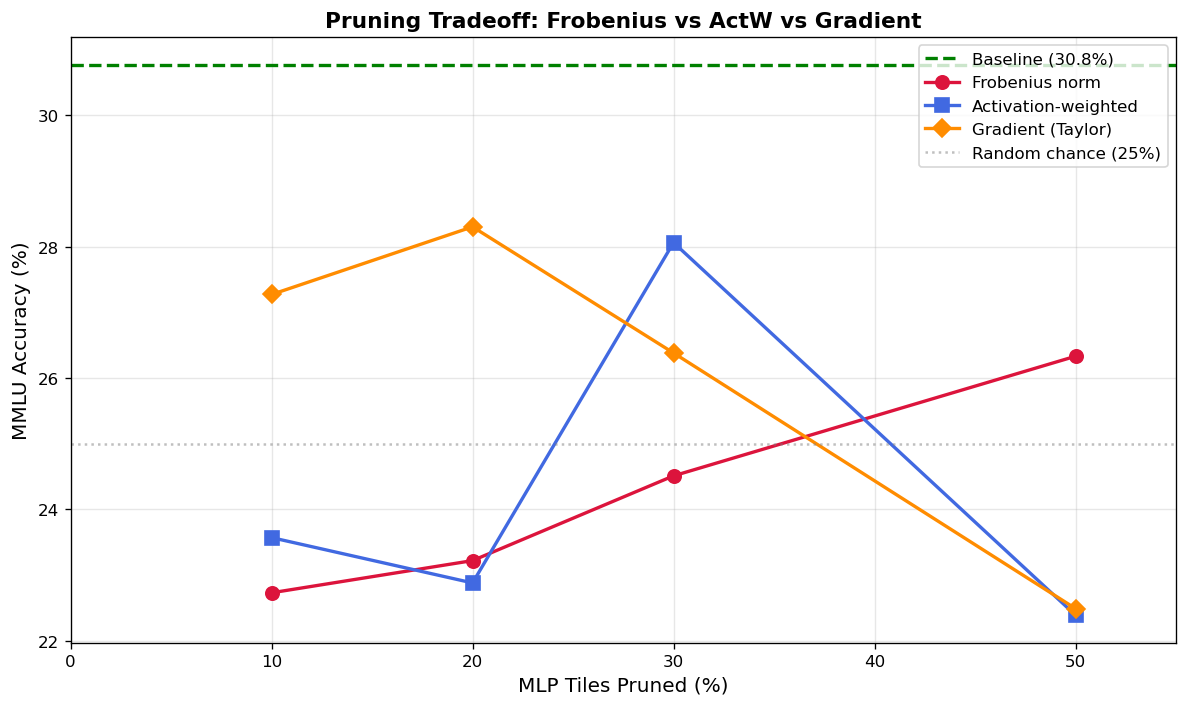

In [21]:
# --- Comparison table ---
print(f"{'Variant':<20s} {'Frobenius':>12s} {'ActWeight':>12s} {'Gradient':>12s} {'Best':>8s}")
print("-" * 68)
if baseline_acc is not None:
    print(f"{'Baseline':<20s} {baseline_acc*100:>11.1f}% {baseline_acc*100:>11.1f}% {baseline_acc*100:>11.1f}%")

for ratio in EVAL_RATIOS:
    frob = all_results[("frobenius", ratio)]["overall"]["accuracy"]
    actw = all_results[("actw", ratio)]["overall"]["accuracy"]
    grad = all_results[("gradient", ratio)]["overall"]["accuracy"]
    best_val = max(frob, actw, grad)
    best_name = {frob: "Frob", actw: "ActW", grad: "Grad"}[best_val]
    print(f"{'Pruned ' + str(int(ratio*100)) + '%':<20s} {frob*100:>11.1f}% {actw*100:>11.1f}% {grad*100:>11.1f}%  {best_name:>6s}")

# --- Tradeoff curves ---
fig, ax = plt.subplots(figsize=(10, 6))

if baseline_acc is not None:
    ax.axhline(baseline_acc * 100, color="green", linestyle="--", linewidth=2,
               label=f"Baseline ({baseline_acc*100:.1f}%)")

frob_accs = [all_results[("frobenius", r)]["overall"]["accuracy"] * 100 for r in EVAL_RATIOS]
actw_accs = [all_results[("actw", r)]["overall"]["accuracy"] * 100 for r in EVAL_RATIOS]
grad_accs = [all_results[("gradient", r)]["overall"]["accuracy"] * 100 for r in EVAL_RATIOS]
x_vals = [r * 100 for r in EVAL_RATIOS]

ax.plot(x_vals, frob_accs, "o-", color="crimson", linewidth=2, markersize=8, label="Frobenius norm")
ax.plot(x_vals, actw_accs, "s-", color="royalblue", linewidth=2, markersize=8, label="Activation-weighted")
ax.plot(x_vals, grad_accs, "D-", color="darkorange", linewidth=2, markersize=8, label="Gradient (Taylor)")

ax.axhline(25.0, color="gray", linestyle=":", alpha=0.5, label="Random chance (25%)")

ax.set_xlabel("MLP Tiles Pruned (%)", fontsize=12)
ax.set_ylabel("MMLU Accuracy (%)", fontsize=12)
ax.set_title("Pruning Tradeoff: Frobenius vs ActW vs Gradient", fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 55)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()